In [ ]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Classical SEMF 
def calculate_semf(A, Z, av=15.8, as_coeff=18.3, ac=0.714, aa=23.2, ap=12.0) :
   # BE = av*A-asA^(2/3)-ac*Z*(Z-1)/A^(1/3)-aa*(N-Z)^2/A + delta
    
    #neutron value
    N = A - Z
    # volume, surface , coulomb , asimetry terms
    e_vol= av*A
    e_surf = as_coeff*(A**(2/3))
    e_coul = ac* (Z*(Z-1))/(A**(1/3)) if A> 0 else 0
    e_asym = aa*((N-Z)**2)/A
   # pairing term
    if Z % 2==0 and N%2 ==0 :
        delta=ap / np.sqrt(A)
    elif Z%2 != 0 and N%2 != 0 :
        delta= -ap/np.sqrt(A)
    else :
        delta = 0.0 
    be_total = e_vol - e_surf - e_coul - e_asym + delta
    return be_total
print("SEMS function defined succesfully")

SEMS function defined succesfully


--- AME2020 DATA PHASE 1 ---
Successfully loaded nuclei count: 3558
Total RMS Error of Classical SEMF Model:: 5.671 MeV


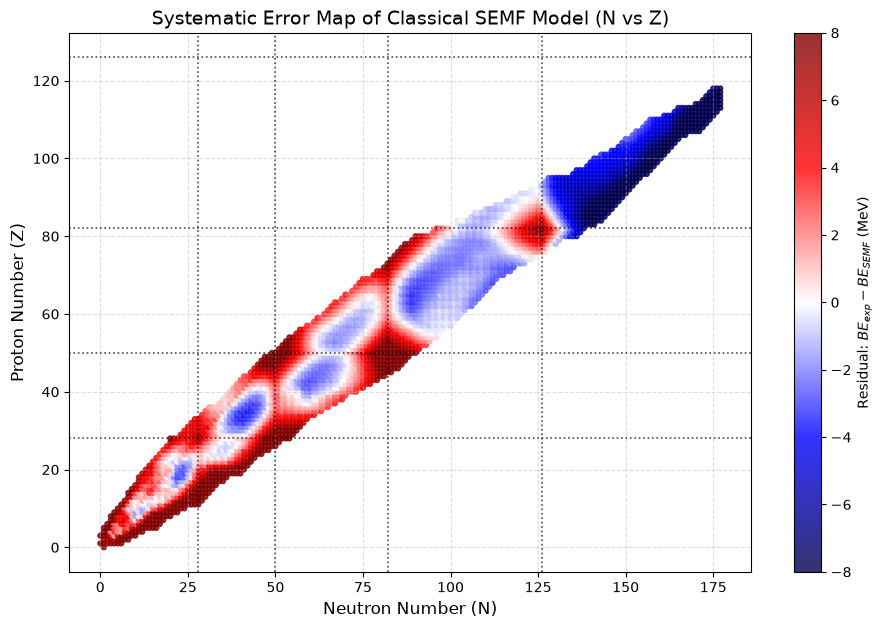

In [ ]:
# PHASE 1 - Testing Classic SEMF Model
# Purpose: Testing the accuracy rate of the SEMF model

file_name = "ame2020.txt"
data =[]

with open(file_name, 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()

for line in lines:
    # Capturing data lines from IAEA
    if len(line) >= 60:
        try:
            # IAEA (Fixed-Width Parsing)
            n_str = line[4:9].strip()
            z_str = line[9:14].strip()
            a_str = line[14:19].strip()
            be_str = line[54:67].strip().replace('*', '').replace('#', '')
            
            # Only take integer N, Z, A values for avoiding headlines
            if n_str.isdigit() and z_str.isdigit() and a_str.isdigit() and be_str:
                n = int(n_str)
                z = int(z_str)
                a = int(a_str)
                
                if a > 0:
                    be_per_a = float(be_str)
                    # keV/A -> Total MeV (BE_per_A * A) / 1000
                    be_exp = (be_per_a * a) / 1000.0
                    data.append({'a': a, 'z': z, 'n': n, 'be_exp': be_exp})
        except ValueError:
            continue

df = pd.DataFrame(data)

# 1. SEMF Predicts
df['be_semf'] = df.apply(lambda r: calculate_semf(int(r['a']), int(r['z'])), axis=1)

# 2. Residual and RMS
df['residual'] = df['be_exp'] - df['be_semf']
rms_error = np.sqrt(np.mean(df['residual']**2))

print(f"--- AME2020 DATA PHASE 1 ---")
print(f"Successfully loaded nuclei count: {len(df)}")
print(f"Total RMS Error of Classical SEMF Model:: {rms_error:.3f} MeV")

# 3. 2D ERROR MAP
plt.figure(figsize=(11, 7))
scatter = plt.scatter(df['n'], df['z'], c=df['residual'], cmap='seismic', vmin=-8, vmax=8, s=12, alpha=0.8)
plt.colorbar(scatter, label='Residual: $BE_{exp} - BE_{SEMF}$ (MeV)')
plt.xlabel('Neutron Number (N)', fontsize=12)
plt.ylabel('Proton Number (Z)', fontsize=12)
plt.title('Systematic Error Map of Classical SEMF Model (N vs Z)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)

# Magic Numbers
for m in [28, 50, 82, 126]:
    plt.axvline(x=m, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
    plt.axhline(y=m, color='black', linestyle=':', linewidth=1.2, alpha=0.7)

plt.show()

=== PHASE 2: HYBRID MODEL EVALUATION ===
Classical SEMF Total RMS Error     : 5.671 MeV
Hybrid Model Test Set RMS Error    : 1.181 MeV
Hybrid Model Full Dataset RMS Error: (In-Sample) 0.626 MeV


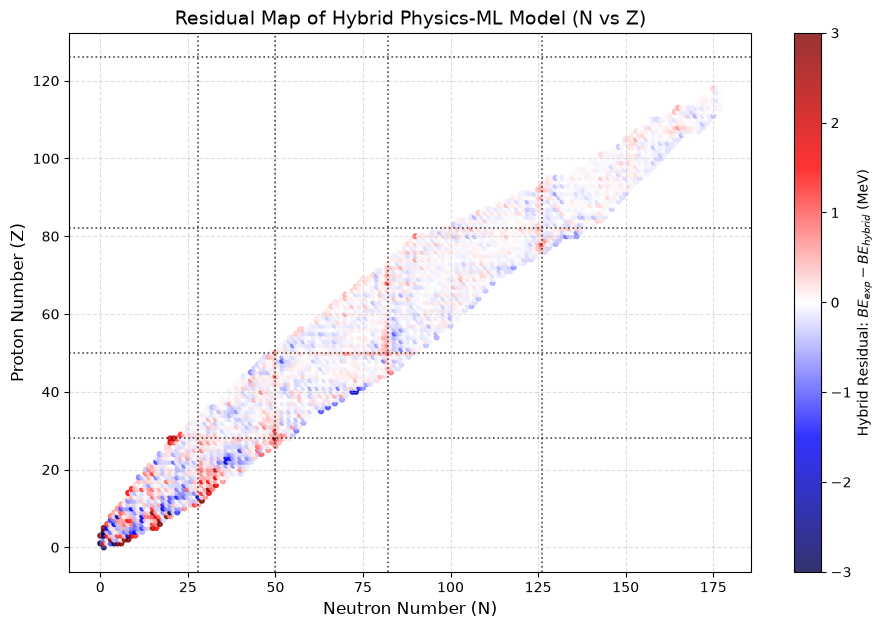

In [8]:
# PHASE 2 — PRELIMINARY HYBRID MODEL
# 80/20 train-test split
# Purpose: Initial demonstration of ML-based residual correction
#
# The in-sample RMSE is reported for diagnostic purposes only
# and is NOT used as the final model performance.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# 1. Feature Engineering with Safe Division (Handling Z=0)
X = df[['n', 'z', 'a']].copy()
X['n_z_ratio'] = np.where(df['z'] == 0, 0.0, df['n'] / df['z'])  # Prevent division by zero
y = df['residual']

# 2. Drop any residual infinity or NaN values if present
valid_mask = np.isfinite(y) & X.isna().sum(axis=1).eq(0)
X = X[valid_mask]
y = y[valid_mask]
df_clean = df[valid_mask].copy()

# 3. Dataset Splitting (80% Training, 20% Testing)
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df_clean, test_size=0.2, random_state=1907
)

# 4. Model Initialization and Training
ml_model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=20, 
    random_state=1907, 
    n_jobs=-1
)
ml_model.fit(X_train, y_train)

# 5. Hybrid Prediction Generation
df_clean['r_pred'] = ml_model.predict(X)
df_clean['be_hybrid'] = df_clean['be_semf'] + df_clean['r_pred']
df_clean['hybrid_residual'] = df_clean['be_exp'] - df_clean['be_hybrid']

# 6. Statistical Performance Evaluation
rms_classic = np.sqrt(np.mean(df_clean['residual']**2))
rms_hybrid_test = root_mean_squared_error(y_test, ml_model.predict(X_test))
rms_hybrid_total = np.sqrt(np.mean(df_clean['hybrid_residual']**2))

print("=== PHASE 2: HYBRID MODEL EVALUATION ===")
print(f"Classical SEMF Total RMS Error     : {rms_classic:.3f} MeV")
print(f"Hybrid Model Test Set RMS Error    : {rms_hybrid_test:.3f} MeV")
print(f"Hybrid Model Full Dataset RMS Error: (In-Sample) {rms_hybrid_total:.3f} MeV")

# 7. Plotting the Corrected 2D Hybrid Residual Map
plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    df_clean['n'], df_clean['z'], 
    c=df_clean['hybrid_residual'], 
    cmap='seismic', 
    vmin=-3, vmax=3, 
    s=12, alpha=0.8
)
plt.colorbar(scatter, label=r'Hybrid Residual: $BE_{exp} - BE_{hybrid}$ (MeV)')
plt.xlabel('Neutron Number (N)', fontsize=12)
plt.ylabel('Proton Number (Z)', fontsize=12)
plt.title('Residual Map of Hybrid Physics-ML Model (N vs Z)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)

# Quantum Shell Closure Lines (Magic Numbers)
magic_numbers = [28, 50, 82, 126]
for m in magic_numbers:
    plt.axvline(x=m, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
    plt.axhline(y=m, color='black', linestyle=':', linewidth=1.2, alpha=0.7)

plt.show()

NUCLEAR MASS RESIDUAL MODELING

Loading AME2020 and experimental beta-2 data...
AME2020 nuclei loaded: 3558
SEMF residuals calculated for 3558 nuclei.
Experimental beta-2 records loaded: 328
Common nuclei with experimental beta-2: 328

Deformation region distribution:
region
Deformed        270
Transitional     54
Spherical         4
Name: count, dtype: int64

CROSS-VALIDATED MODEL COMPARISON

Dataset size: 328 nuclei
Validation: 5-fold cross-validation
All models use identical folds and test nuclei.

Random Forest
--------------------------------------------------
A (Geometry)             : 1.1021 +/- 0.0838 MeV
B (Absolute Shell)       : 0.8517 +/- 0.1343 MeV
C (Signed Shell)         : 0.8476 +/- 0.0713 MeV
D1 (Signed Beta-2)       : 0.9486 +/- 0.0980 MeV
D2 (Absolute Beta-2)     : 0.9486 +/- 0.0980 MeV
D3 (Squared Beta-2)      : 0.9488 +/- 0.0977 MeV

Extra Trees
--------------------------------------------------
A (Geometry)             : 1.0018 +/- 0.1057 MeV
B (Absolute Shell)   

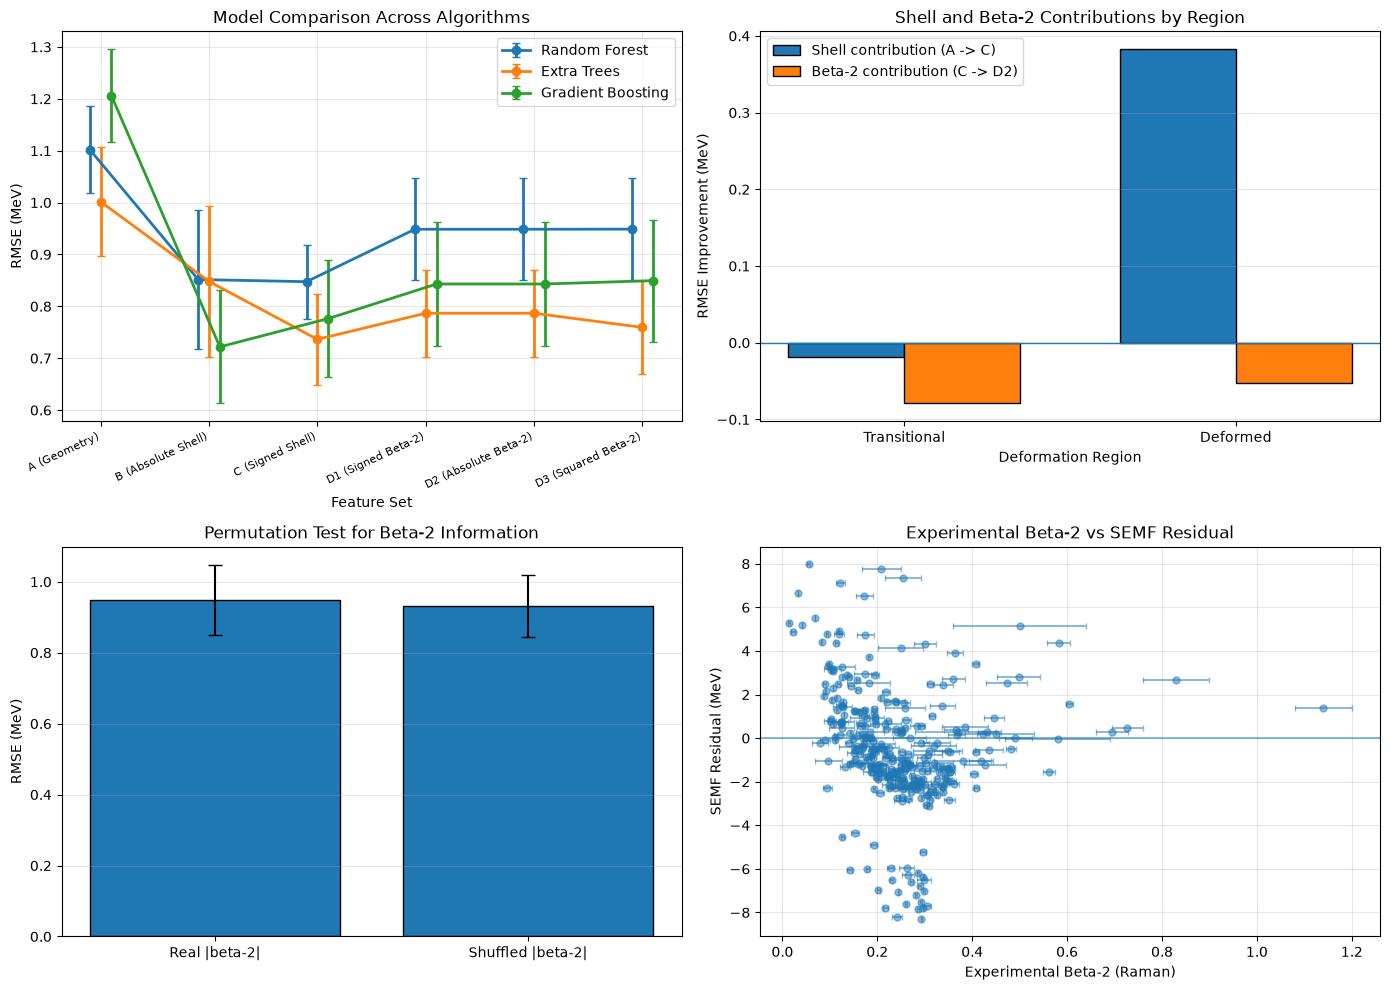


CORRELATION ANALYSIS
Beta-2 vs magic_dist_Z        : +0.150
Beta-2 vs magic_dist_N        : +0.119
|Beta-2| vs |Residual|        : -0.061
Beta-2 vs Residual            : -0.182

ANALYSIS COMPLETE


In [9]:
# ============================================================
# NUCLEAR MASS RESIDUAL MODELING
# Experimental Beta-2 Ablation Study
# ============================================================

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import wilcoxon

from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor
)
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold


warnings.filterwarnings("ignore")


# ============================================================
# 1. DATA LOADING
#    AME2020 + Experimental Raman Beta-2
# ============================================================

print("=" * 70)
print("NUCLEAR MASS RESIDUAL MODELING")
print("=" * 70)
print("\nLoading AME2020 and experimental beta-2 data...")


# ------------------------------------------------------------
# 1.1 Load AME2020
# ------------------------------------------------------------

ame_file = "ame2020.txt"
ame_data = []

with open(ame_file, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

for line in lines:

    if len(line) < 60:
        continue

    try:
        # AME2020 uses fixed-width formatting
        n_str = line[4:9].strip()
        z_str = line[9:14].strip()
        a_str = line[14:19].strip()

        be_str = (
            line[54:67]
            .strip()
            .replace("*", "")
            .replace("#", "")
            .strip()
        )

        if (
            n_str.isdigit()
            and z_str.isdigit()
            and a_str.isdigit()
            and be_str
        ):

            n = int(n_str)
            z = int(z_str)
            a = int(a_str)

            # Keep only valid nuclei
            if a > 0 and be_str.replace("-", "").replace(".", "").isdigit():

                # AME2020 binding energy per nucleon:
                # keV / nucleon -> total binding energy in MeV
                be_exp = (float(be_str) * a) / 1000.0

                ame_data.append(
                    {
                        "n": n,
                        "z": z,
                        "a": a,
                        "BE_exp": be_exp
                    }
                )

    except (ValueError, IndexError):
        continue


df_ame = pd.DataFrame(ame_data)

df_ame = df_ame.drop_duplicates(
    subset=["z", "n", "a"]
).reset_index(drop=True)

print(f"AME2020 nuclei loaded: {len(df_ame)}")


# ============================================================
# 2. SEMF BASELINE
# ============================================================

def calculate_semf(
    A,
    Z,
    av=15.8,
    as_coeff=18.3,
    ac=0.714,
    aa=23.2,
    ap=12.0
):
    """
    Calculate nuclear binding energy using the classical
    Semi-Empirical Mass Formula (SEMF).

    Parameters
    ----------
    A : int
        Mass number.
    Z : int
        Proton number.
    av : float
        Volume-term coefficient.
    as_coeff : float
        Surface-term coefficient.
    ac : float
        Coulomb-term coefficient.
    aa : float
        Asymmetry-term coefficient.
    ap : float
        Pairing-term coefficient.

    Returns
    -------
    float
        SEMF binding energy in MeV.
    """

    N = A - Z

    # Volume term
    e_vol = av * A

    # Surface term
    e_surf = as_coeff * A ** (2 / 3)

    # Coulomb term
    e_coul = (
        ac * Z * (Z - 1) / A ** (1 / 3)
        if A > 0
        else 0.0
    )

    # Asymmetry term
    e_asym = aa * (N - Z) ** 2 / A

    # Pairing term
    if Z % 2 == 0 and N % 2 == 0:
        delta = ap / np.sqrt(A)

    elif Z % 2 != 0 and N % 2 != 0:
        delta = -ap / np.sqrt(A)

    else:
        delta = 0.0

    return (
        e_vol
        - e_surf
        - e_coul
        - e_asym
        + delta
    )


df_ame["BE_SEMF"] = df_ame.apply(
    lambda row: calculate_semf(
        int(row["a"]),
        int(row["z"])
    ),
    axis=1
)

df_ame["residual"] = (
    df_ame["BE_exp"] - df_ame["BE_SEMF"]
)

print(
    f"SEMF residuals calculated for "
    f"{len(df_ame)} nuclei."
)


# ============================================================
# 3. LOAD EXPERIMENTAL BETA-2 DATA
#    Raman Quadrupole Deformation Dataset
# ============================================================

def load_raman_beta2(filename="beta2.txt"):
    """
    Load experimental quadrupole deformation beta-2
    values from the Raman dataset.

    Expected format:
        Z  A  El  beta2  Error

    Returns
    -------
    pandas.DataFrame
        Experimental beta-2 values and uncertainties.
    """

    data = []

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:

        for line in f:

            line = line.strip()

            if (
                not line
                or line.startswith("#")
                or line.startswith("-")
            ):
                continue

            parts = line.split()

            if len(parts) < 5:
                continue

            try:
                z = int(parts[0])
                a = int(parts[1])

                beta2 = float(parts[3])
                beta2_err = float(parts[4])

                n = a - z

                data.append(
                    {
                        "z": z,
                        "n": n,
                        "a": a,
                        "beta_2": beta2,
                        "beta2_err": beta2_err
                    }
                )

            except (ValueError, IndexError):
                continue

    return pd.DataFrame(data)


df_beta2 = load_raman_beta2("beta2.txt")

print(f"Experimental beta-2 records loaded: {len(df_beta2)}")


# ============================================================
# 4. MERGE AME2020 AND BETA-2 DATA
# ============================================================

df_analysis = pd.merge(
    df_ame,
    df_beta2[
        [
            "z",
            "n",
            "beta_2",
            "beta2_err"
        ]
    ],
    on=["z", "n"],
    how="inner"
)

print(
    f"Common nuclei with experimental beta-2: "
    f"{len(df_analysis)}"
)


# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

# Nuclear magic numbers used for shell-related features
magic_numbers = np.array(
    [2, 8, 20, 28, 50, 82, 126]
)


def get_min_magic_dist(x):
    """
    Return the absolute distance from the nearest
    nuclear magic number.
    """
    return np.min(
        np.abs(magic_numbers - x)
    )


def get_signed_magic_dist(x):
    """
    Return the signed distance from the nearest
    nuclear magic number.
    """
    closest_magic = magic_numbers[
        np.argmin(
            np.abs(magic_numbers - x)
        )
    ]

    return x - closest_magic


# Shell-related features
df_analysis["magic_dist_Z"] = (
    df_analysis["z"].apply(get_min_magic_dist)
)

df_analysis["magic_dist_N"] = (
    df_analysis["n"].apply(get_min_magic_dist)
)

df_analysis["valence_Z"] = (
    df_analysis["z"].apply(get_signed_magic_dist)
)

df_analysis["valence_N"] = (
    df_analysis["n"].apply(get_signed_magic_dist)
)

# Parity features
df_analysis["parity_Z"] = (
    df_analysis["z"] % 2
)

df_analysis["parity_N"] = (
    df_analysis["n"] % 2
)

# Neutron excess
df_analysis["neutron_excess"] = (
    (df_analysis["n"] - df_analysis["z"])
    / df_analysis["a"]
)

# Beta-2 transformations
df_analysis["beta2_abs"] = (
    np.abs(df_analysis["beta_2"])
)

df_analysis["beta2_sq"] = (
    df_analysis["beta_2"] ** 2
)


# ============================================================
# 6. DEFORMATION REGION CLASSIFICATION
# ============================================================

def assign_deformation_region(beta2):
    """
    Assign an operational deformation category
    based on the absolute beta-2 value.

    These thresholds are used as analysis bins and
    are not intended as strict physical classifications.
    """

    abs_beta2 = abs(beta2)

    if abs_beta2 < 0.05:
        return "Spherical"

    elif abs_beta2 < 0.15:
        return "Transitional"

    else:
        return "Deformed"


df_analysis["region"] = (
    df_analysis["beta_2"]
    .apply(assign_deformation_region)
)

print("\nDeformation region distribution:")
print(
    df_analysis["region"].value_counts()
)


# ============================================================
# 7. MODEL DEFINITIONS
# ============================================================

target = "residual"


# Model A: Basic nuclear geometry
features_A = [
    "z",
    "n",
    "a"
]


# Model B: Geometry + absolute shell-distance features
features_B = [
    "z",
    "n",
    "a",
    "magic_dist_Z",
    "magic_dist_N",
    "parity_Z",
    "parity_N",
    "neutron_excess"
]


# Model C: Geometry + signed shell/valence features
features_C = [
    "z",
    "n",
    "a",
    "valence_Z",
    "valence_N",
    "parity_Z",
    "parity_N",
    "neutron_excess"
]


# Model D1: Model C + signed beta-2
features_D1 = (
    features_C
    + ["beta_2"]
)


# Model D2: Model C + absolute beta-2
features_D2 = (
    features_C
    + ["beta2_abs"]
)


# Model D3: Model C + squared beta-2
features_D3 = (
    features_C
    + ["beta2_sq"]
)


features_list = {
    "A (Geometry)": features_A,
    "B (Absolute Shell)": features_B,
    "C (Signed Shell)": features_C,
    "D1 (Signed Beta-2)": features_D1,
    "D2 (Absolute Beta-2)": features_D2,
    "D3 (Squared Beta-2)": features_D3,
}


# ============================================================
# 8. CROSS-VALIDATED MODEL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("CROSS-VALIDATED MODEL COMPARISON")
print("=" * 70)

print(
    f"\nDataset size: {len(df_analysis)} nuclei"
)

print(
    "Validation: 5-fold cross-validation"
)

print(
    "All models use identical folds and test nuclei."
)


def run_model_comparison(
    df,
    features_list,
    model_generator
):
    """
    Evaluate all feature sets using identical
    5-fold cross-validation splits.

    Returns
    -------
    dict
        Mean and standard deviation of RMSE
        across the five folds.
    """

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    results = {}

    for feature_name, features in features_list.items():

        rmse_scores = []

        for train_idx, test_idx in kf.split(df):

            train_data = df.iloc[train_idx]
            test_data = df.iloc[test_idx]

            y_train = train_data[target]
            y_test = test_data[target]

            model = model_generator()

            model.fit(
                train_data[features],
                y_train
            )

            y_pred = model.predict(
                test_data[features]
            )

            rmse = root_mean_squared_error(
                y_test,
                y_pred
            )

            rmse_scores.append(rmse)

        results[feature_name] = {
            "mean": np.mean(rmse_scores),
            "std": np.std(rmse_scores)
        }

    return results


# ============================================================
# 9. ALGORITHM ROBUSTNESS
# ============================================================

algorithms = {

    "Random Forest": lambda:
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees": lambda:
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting": lambda:
        GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        )
}


all_results = {}


for algorithm_name, algorithm_generator in algorithms.items():

    print(
        f"\n{algorithm_name}"
    )

    print("-" * 50)

    results = run_model_comparison(
        df_analysis,
        features_list,
        algorithm_generator
    )

    all_results[algorithm_name] = results

    for feature_name, result in results.items():

        print(
            f"{feature_name:25s}: "
            f"{result['mean']:.4f} "
            f"+/- {result['std']:.4f} MeV"
        )


# ============================================================
# 10. REGIONAL ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("REGIONAL DEFORMATION ANALYSIS")
print("=" * 70)

print(
    "\nNote: deformation regions are operational analysis bins, "
    "not strict physical classifications."
)


region_results = {}


for region in [
    "Spherical",
    "Transitional",
    "Deformed"
]:

    df_region = (
        df_analysis[
            df_analysis["region"] == region
        ]
        .copy()
    )

    if len(df_region) < 20:

        print(
            f"\n{region}: insufficient sample size "
            f"(n={len(df_region)})"
        )

        continue

    print(
        f"\n{region.upper()} "
        f"(n={len(df_region)})"
    )

    print("-" * 50)

    results = run_model_comparison(
        df_region,
        features_list,
        lambda:
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
    )

    region_results[region] = results

    for feature_name, result in results.items():

        print(
            f"{feature_name:25s}: "
            f"{result['mean']:.4f} "
            f"+/- {result['std']:.4f} MeV"
        )

    rmse_A = (
        results["A (Geometry)"]["mean"]
    )

    rmse_C = (
        results["C (Signed Shell)"]["mean"]
    )

    rmse_D2 = (
        results["D2 (Absolute Beta-2)"]["mean"]
    )

    print(
        f"\nShell contribution (A -> C): "
        f"{rmse_A - rmse_C:+.4f} MeV"
    )

    print(
        f"Beta-2 contribution (C -> D2): "
        f"{rmse_C - rmse_D2:+.4f} MeV"
    )


# ============================================================
# 11. PERMUTATION TEST
# ============================================================

print("\n" + "=" * 70)
print("PERMUTATION TEST FOR BETA-2 INFORMATION")
print("=" * 70)


np.random.seed(42)

df_perm = df_analysis.copy()

df_perm["beta2_abs_shuffled"] = (
    np.random.permutation(
        df_perm["beta2_abs"].values
    )
)

features_D2_shuffled = (
    features_C
    + ["beta2_abs_shuffled"]
)


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rmse_real = []
rmse_shuffled = []


for train_idx, test_idx in kf.split(df_perm):

    train_data = df_perm.iloc[train_idx]
    test_data = df_perm.iloc[test_idx]

    y_train = train_data[target]
    y_test = test_data[target]

    # Model with real beta-2
    model_real = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_real.fit(
        train_data[features_D2],
        y_train
    )

    prediction_real = model_real.predict(
        test_data[features_D2]
    )

    rmse_real.append(
        root_mean_squared_error(
            y_test,
            prediction_real
        )
    )

    # Model with shuffled beta-2
    model_shuffled = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_shuffled.fit(
        train_data[features_D2_shuffled],
        y_train
    )

    prediction_shuffled = (
        model_shuffled.predict(
            test_data[features_D2_shuffled]
        )
    )

    rmse_shuffled.append(
        root_mean_squared_error(
            y_test,
            prediction_shuffled
        )
    )


statistic, p_value = wilcoxon(
    rmse_real,
    rmse_shuffled
)


print(
    f"\nReal |beta-2|: "
    f"{np.mean(rmse_real):.4f} "
    f"+/- {np.std(rmse_real):.4f} MeV"
)

print(
    f"Shuffled |beta-2|: "
    f"{np.mean(rmse_shuffled):.4f} "
    f"+/- {np.std(rmse_shuffled):.4f} MeV"
)

print(
    f"Difference: "
    f"{np.mean(rmse_real) - np.mean(rmse_shuffled):+.4f} MeV"
)

print(
    f"Wilcoxon p-value: "
    f"{p_value:.4f}"
)

if np.mean(rmse_real) < np.mean(rmse_shuffled):

    print(
        "Result: Real beta-2 provides lower RMSE."
    )

else:

    print(
        "Result: Real beta-2 does not improve RMSE."
    )


# ============================================================
# 12. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)


# ------------------------------------------------------------
# 12.1 Global Model Comparison
# ------------------------------------------------------------

feature_names = list(
    features_list.keys()
)

x_positions = np.arange(
    len(feature_names)
)


for i, (
    algorithm_name,
    results
) in enumerate(all_results.items()):

    rmse_values = [
        results[feature]["mean"]
        for feature in feature_names
    ]

    rmse_stds = [
        results[feature]["std"]
        for feature in feature_names
    ]

    axes[0, 0].errorbar(
        x_positions + (i - 1) * 0.1,
        rmse_values,
        yerr=rmse_stds,
        fmt="o-",
        label=algorithm_name,
        linewidth=2,
        markersize=6,
        capsize=3
    )


axes[0, 0].set_xlabel(
    "Feature Set"
)

axes[0, 0].set_ylabel(
    "RMSE (MeV)"
)

axes[0, 0].set_title(
    "Model Comparison Across Algorithms"
)

axes[0, 0].set_xticks(
    x_positions
)

axes[0, 0].set_xticklabels(
    feature_names,
    rotation=25,
    ha="right",
    fontsize=8
)

axes[0, 0].legend()

axes[0, 0].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# 12.2 Regional Shell and Beta-2 Contributions
# ------------------------------------------------------------

regions = list(
    region_results.keys()
)

shell_improvements = []
beta2_improvements = []


for region in regions:

    shell_improvements.append(
        region_results[region][
            "A (Geometry)"
        ]["mean"]
        -
        region_results[region][
            "C (Signed Shell)"
        ]["mean"]
    )

    beta2_improvements.append(
        region_results[region][
            "C (Signed Shell)"
        ]["mean"]
        -
        region_results[region][
            "D2 (Absolute Beta-2)"
        ]["mean"]
    )


x_positions = np.arange(
    len(regions)
)

width = 0.35


axes[0, 1].bar(
    x_positions - width / 2,
    shell_improvements,
    width,
    label="Shell contribution (A -> C)",
    edgecolor="black"
)

axes[0, 1].bar(
    x_positions + width / 2,
    beta2_improvements,
    width,
    label="Beta-2 contribution (C -> D2)",
    edgecolor="black"
)

axes[0, 1].axhline(
    y=0,
    linestyle="-",
    linewidth=1
)

axes[0, 1].set_xlabel(
    "Deformation Region"
)

axes[0, 1].set_ylabel(
    "RMSE Improvement (MeV)"
)

axes[0, 1].set_title(
    "Shell and Beta-2 Contributions by Region"
)

axes[0, 1].set_xticks(
    x_positions
)

axes[0, 1].set_xticklabels(
    regions
)

axes[0, 1].legend()

axes[0, 1].grid(
    True,
    alpha=0.3,
    axis="y"
)


# ------------------------------------------------------------
# 12.3 Permutation Test
# ------------------------------------------------------------

axes[1, 0].bar(
    [
        "Real |beta-2|",
        "Shuffled |beta-2|"
    ],
    [
        np.mean(rmse_real),
        np.mean(rmse_shuffled)
    ],
    yerr=[
        np.std(rmse_real),
        np.std(rmse_shuffled)
    ],
    edgecolor="black",
    capsize=5
)

axes[1, 0].set_ylabel(
    "RMSE (MeV)"
)

axes[1, 0].set_title(
    "Permutation Test for Beta-2 Information"
)

axes[1, 0].grid(
    True,
    alpha=0.3,
    axis="y"
)


# ------------------------------------------------------------
# 12.4 Experimental Beta-2 vs SEMF Residual
# ------------------------------------------------------------

axes[1, 1].errorbar(
    df_analysis["beta_2"],
    df_analysis["residual"],
    xerr=df_analysis["beta2_err"],
    fmt="o",
    alpha=0.5,
    capsize=2,
    markersize=5
)

axes[1, 1].set_xlabel(
    "Experimental Beta-2 (Raman)"
)

axes[1, 1].set_ylabel(
    "SEMF Residual (MeV)"
)

axes[1, 1].set_title(
    "Experimental Beta-2 vs SEMF Residual"
)

axes[1, 1].axhline(
    y=0,
    linestyle="-",
    alpha=0.5
)

axes[1, 1].grid(
    True,
    alpha=0.3
)


plt.tight_layout()
plt.show()


# ============================================================
# 13. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)


correlations = {

    "Beta-2 vs magic_dist_Z":
        df_analysis["beta_2"].corr(
            df_analysis["magic_dist_Z"]
        ),

    "Beta-2 vs magic_dist_N":
        df_analysis["beta_2"].corr(
            df_analysis["magic_dist_N"]
        ),

    "|Beta-2| vs |Residual|":
        df_analysis["beta2_abs"].corr(
            np.abs(df_analysis["residual"])
        ),

    "Beta-2 vs Residual":
        df_analysis["beta_2"].corr(
            df_analysis["residual"]
        )
}


for name, correlation in correlations.items():

    print(
        f"{name:30s}: "
        f"{correlation:+.3f}"
    )


# ============================================================
# 14. COMPLETION
# ============================================================

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

PHASE 4: GPR UNCERTAINTY ANALYSIS

Training GPR models using 5-fold cross-validation...
This step may take several minutes.

Fold 1/5 completed
Fold 2/5 completed
Fold 3/5 completed
Fold 4/5 completed
Fold 5/5 completed

GPR PERFORMANCE AND UNCERTAINTY SUMMARY

Model C — Shell Features
  RMSE: 0.6703 MeV
  Mean predicted uncertainty (σ): 0.5912 MeV
  Mean |residual| / σ ratio: 0.6184

Model D2 — Shell Features + |β₂|
  RMSE: 0.7745 MeV
  Mean predicted uncertainty (σ): 0.6289 MeV
  Mean |residual| / σ ratio: 0.5934


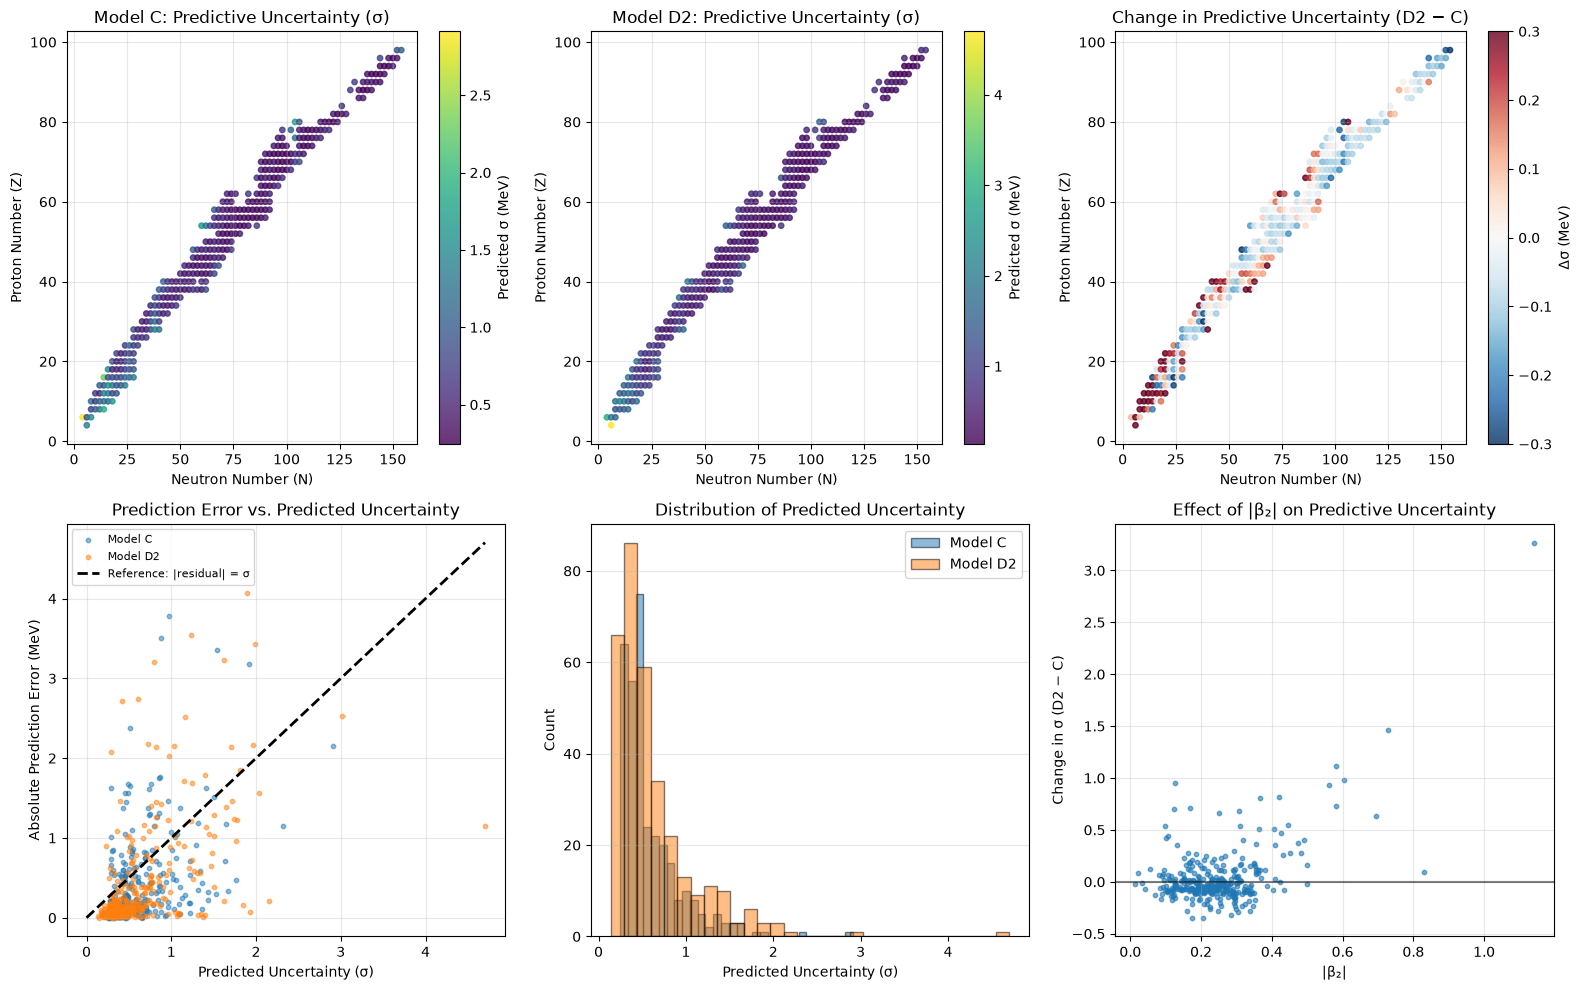


REGIONAL UNCERTAINTY ANALYSIS

TRANSITIONAL (n=54)
  Model C: RMSE=0.8263 MeV, σ=0.4753 MeV
  Model D2: RMSE=0.9999 MeV, σ=0.5039 MeV
  Change in mean uncertainty: +0.0287 MeV

DEFORMED (n=270)
  Model C: RMSE=0.6194 MeV, σ=0.6162 MeV
  Model D2: RMSE=0.7045 MeV, σ=0.6563 MeV
  Change in mean uncertainty: +0.0401 MeV

GPR UNCERTAINTY ANALYSIS COMPLETED


In [10]:
# ============================================================
# PHASE 4 — GPR UNCERTAINTY ANALYSIS
# ============================================================
# Purpose:
# Evaluate predictive uncertainty using Gaussian Process Regression
# and investigate whether adding experimental quadrupole deformation
# (|β₂|) improves predictive accuracy or uncertainty estimates.
#
# Models:
#   Model C  = Shell-based feature set
#   Model D2 = Model C + experimental |β₂|
#
# Evaluation:
#   5-fold cross-validation with out-of-fold predictions
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    WhiteKernel,
    ConstantKernel as C,
    Matern
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. KERNEL CONFIGURATION
# ============================================================

kernels = {
    "RBF": (
        C(1.0)
        * RBF(length_scale=1.0)
        + WhiteKernel(noise_level=0.1)
    ),

    "Matern": (
        C(1.0)
        * Matern(length_scale=1.0, nu=1.5)
        + WhiteKernel(noise_level=0.1)
    ),

    "RBF+Linear": (
        C(1.0)
        * RBF(length_scale=1.0)
        + C(1.0)
        + WhiteKernel(noise_level=0.1)
    ),
}


# ============================================================
# 2. FEATURE DEFINITIONS
# ============================================================

target = "residual"

# Model C: Shell-based features without experimental β₂
features_C = [
    "z",
    "n",
    "a",
    "valence_Z",
    "valence_N",
    "parity_Z",
    "parity_N",
    "neutron_excess",
]

# Model D2: Model C + absolute experimental β₂
features_D2 = features_C + ["beta2_abs"]


# ============================================================
# 3. CROSS-VALIDATION SETUP
# ============================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

n_samples = len(df_analysis)

# Out-of-fold predictions
oof_pred_C = np.zeros(n_samples)
oof_std_C = np.zeros(n_samples)

oof_pred_D2 = np.zeros(n_samples)
oof_std_D2 = np.zeros(n_samples)


# ============================================================
# 4. OUT-OF-FOLD GPR PREDICTIONS
# ============================================================

print("=" * 70)
print("PHASE 4: GPR UNCERTAINTY ANALYSIS")
print("=" * 70)

print("\nTraining GPR models using 5-fold cross-validation...")
print("This step may take several minutes.\n")


for fold, (train_idx, test_idx) in enumerate(kf.split(df_analysis)):

    train_data = df_analysis.iloc[train_idx]
    test_data = df_analysis.iloc[test_idx]

    y_train = train_data[target]

    # --------------------------------------------------------
    # Model C: Shell-based model
    # --------------------------------------------------------

    model_C = Pipeline([
        ("scaler", StandardScaler()),
        (
            "gpr",
            GaussianProcessRegressor(
                kernel=kernels["Matern"],
                n_restarts_optimizer=3,
                random_state=42
            )
        )
    ])

    model_C.fit(
        train_data[features_C],
        y_train
    )

    pred_C, std_C = model_C.predict(
        test_data[features_C],
        return_std=True
    )

    oof_pred_C[test_idx] = pred_C
    oof_std_C[test_idx] = std_C

    # --------------------------------------------------------
    # Model D2: Shell + |β₂|
    # --------------------------------------------------------

    model_D2 = Pipeline([
        ("scaler", StandardScaler()),
        (
            "gpr",
            GaussianProcessRegressor(
                kernel=kernels["Matern"],
                n_restarts_optimizer=3,
                random_state=42
            )
        )
    ])

    model_D2.fit(
        train_data[features_D2],
        y_train
    )

    pred_D2, std_D2 = model_D2.predict(
        test_data[features_D2],
        return_std=True
    )

    oof_pred_D2[test_idx] = pred_D2
    oof_std_D2[test_idx] = std_D2

    print(f"Fold {fold + 1}/5 completed")


# ============================================================
# 5. PREDICTION ERROR AND UNCERTAINTY METRICS
# ============================================================

# Out-of-fold residuals
residuals_C = (
    df_analysis[target].values - oof_pred_C
)

residuals_D2 = (
    df_analysis[target].values - oof_pred_D2
)


# RMSE
rmse_C = root_mean_squared_error(
    df_analysis[target].values,
    oof_pred_C
)

rmse_D2 = root_mean_squared_error(
    df_analysis[target].values,
    oof_pred_D2
)


# Mean predicted uncertainty
mean_std_C = np.mean(oof_std_C)
mean_std_D2 = np.mean(oof_std_D2)


# Mean absolute residual-to-uncertainty ratio
# Used here as a simple uncertainty consistency diagnostic.
calibration_C = np.mean(
    np.abs(residuals_C) / np.maximum(oof_std_C, 1e-12)
)

calibration_D2 = np.mean(
    np.abs(residuals_D2) / np.maximum(oof_std_D2, 1e-12)
)


# ============================================================
# 6. SUMMARY OF GPR RESULTS
# ============================================================

print("\n" + "=" * 70)
print("GPR PERFORMANCE AND UNCERTAINTY SUMMARY")
print("=" * 70)

print("\nModel C — Shell Features")
print(f"  RMSE: {rmse_C:.4f} MeV")
print(f"  Mean predicted uncertainty (σ): {mean_std_C:.4f} MeV")
print(
    f"  Mean |residual| / σ ratio: "
    f"{calibration_C:.4f}"
)

print("\nModel D2 — Shell Features + |β₂|")
print(f"  RMSE: {rmse_D2:.4f} MeV")
print(f"  Mean predicted uncertainty (σ): {mean_std_D2:.4f} MeV")
print(
    f"  Mean |residual| / σ ratio: "
    f"{calibration_D2:.4f}"
)


# ============================================================
# 7. UNCERTAINTY MAPS IN THE N-Z PLANE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)


# ------------------------------------------------------------
# Plot 1: Model C uncertainty
# ------------------------------------------------------------

sc1 = axes[0, 0].scatter(
    df_analysis["n"],
    df_analysis["z"],
    c=oof_std_C,
    cmap="viridis",
    s=15,
    alpha=0.8
)

axes[0, 0].set_xlabel("Neutron Number (N)")
axes[0, 0].set_ylabel("Proton Number (Z)")
axes[0, 0].set_title(
    "Model C: Predictive Uncertainty (σ)"
)

axes[0, 0].grid(True, alpha=0.3)

plt.colorbar(
    sc1,
    ax=axes[0, 0],
    label="Predicted σ (MeV)"
)


# ------------------------------------------------------------
# Plot 2: Model D2 uncertainty
# ------------------------------------------------------------

sc2 = axes[0, 1].scatter(
    df_analysis["n"],
    df_analysis["z"],
    c=oof_std_D2,
    cmap="viridis",
    s=15,
    alpha=0.8
)

axes[0, 1].set_xlabel("Neutron Number (N)")
axes[0, 1].set_ylabel("Proton Number (Z)")
axes[0, 1].set_title(
    "Model D2: Predictive Uncertainty (σ)"
)

axes[0, 1].grid(True, alpha=0.3)

plt.colorbar(
    sc2,
    ax=axes[0, 1],
    label="Predicted σ (MeV)"
)


# ------------------------------------------------------------
# Plot 3: Change in predicted uncertainty
# ------------------------------------------------------------

diff_std = oof_std_D2 - oof_std_C

sc3 = axes[0, 2].scatter(
    df_analysis["n"],
    df_analysis["z"],
    c=diff_std,
    cmap="RdBu_r",
    s=15,
    alpha=0.8,
    vmin=-0.3,
    vmax=0.3
)

axes[0, 2].set_xlabel("Neutron Number (N)")
axes[0, 2].set_ylabel("Proton Number (Z)")
axes[0, 2].set_title(
    "Change in Predictive Uncertainty (D2 − C)"
)

axes[0, 2].grid(True, alpha=0.3)

plt.colorbar(
    sc3,
    ax=axes[0, 2],
    label="Δσ (MeV)"
)


# ============================================================
# 8. UNCERTAINTY CONSISTENCY PLOT
# ============================================================

axes[1, 0].scatter(
    oof_std_C,
    np.abs(residuals_C),
    alpha=0.5,
    s=10,
    label="Model C"
)

axes[1, 0].scatter(
    oof_std_D2,
    np.abs(residuals_D2),
    alpha=0.5,
    s=10,
    label="Model D2"
)

max_value = max(
    oof_std_C.max(),
    oof_std_D2.max()
)

axes[1, 0].plot(
    [0, max_value],
    [0, max_value],
    "k--",
    linewidth=2,
    label="Reference: |residual| = σ"
)

axes[1, 0].set_xlabel(
    "Predicted Uncertainty (σ)"
)

axes[1, 0].set_ylabel(
    "Absolute Prediction Error (MeV)"
)

axes[1, 0].set_title(
    "Prediction Error vs. Predicted Uncertainty"
)

axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)


# ============================================================
# 9. UNCERTAINTY DISTRIBUTION
# ============================================================

axes[1, 1].hist(
    oof_std_C,
    bins=30,
    alpha=0.5,
    label="Model C",
    edgecolor="black"
)

axes[1, 1].hist(
    oof_std_D2,
    bins=30,
    alpha=0.5,
    label="Model D2",
    edgecolor="black"
)

axes[1, 1].set_xlabel(
    "Predicted Uncertainty (σ)"
)

axes[1, 1].set_ylabel(
    "Count"
)

axes[1, 1].set_title(
    "Distribution of Predicted Uncertainty"
)

axes[1, 1].legend()
axes[1, 1].grid(
    True,
    alpha=0.3,
    axis="y"
)


# ============================================================
# 10. β₂ VS UNCERTAINTY CHANGE
# ============================================================

axes[1, 2].scatter(
    df_analysis["beta2_abs"],
    diff_std,
    alpha=0.6,
    s=10
)

axes[1, 2].axhline(
    y=0,
    color="black",
    linestyle="-",
    alpha=0.5
)

axes[1, 2].set_xlabel("|β₂|")
axes[1, 2].set_ylabel("Change in σ (D2 − C)")
axes[1, 2].set_title(
    "Effect of |β₂| on Predictive Uncertainty"
)

axes[1, 2].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


# ============================================================
# 11. REGIONAL UNCERTAINTY ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("REGIONAL UNCERTAINTY ANALYSIS")
print("=" * 70)


for region in [
    "Spherical",
    "Transitional",
    "Deformed"
]:

    mask = (
        df_analysis["region"].values == region
    )

    n_region = mask.sum()

    if n_region < 20:
        continue

    rmse_C_region = root_mean_squared_error(
        df_analysis[target].values[mask],
        oof_pred_C[mask]
    )

    rmse_D2_region = root_mean_squared_error(
        df_analysis[target].values[mask],
        oof_pred_D2[mask]
    )

    std_C_region = np.mean(
        oof_std_C[mask]
    )

    std_D2_region = np.mean(
        oof_std_D2[mask]
    )

    print(f"\n{region.upper()} (n={n_region})")

    print(
        f"  Model C: "
        f"RMSE={rmse_C_region:.4f} MeV, "
        f"σ={std_C_region:.4f} MeV"
    )

    print(
        f"  Model D2: "
        f"RMSE={rmse_D2_region:.4f} MeV, "
        f"σ={std_D2_region:.4f} MeV"
    )

    print(
        f"  Change in mean uncertainty: "
        f"{std_D2_region - std_C_region:+.4f} MeV"
    )


# ============================================================
# 12. COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("GPR UNCERTAINTY ANALYSIS COMPLETED")
print("=" * 70)

PHASE 5 — FEATURE IMPORTANCE ANALYSIS

Number of nuclei: 328
Model C features:  8
Model D2 features: 9

RANDOM FOREST PERMUTATION IMPORTANCE

Model C — Shell Features
------------------------------------------------------------
neutron_excess      : 0.3555 ± 0.0274
valence_N           : 0.3552 ± 0.0272
a                   : 0.2034 ± 0.0175
n                   : 0.1724 ± 0.0164
z                   : 0.0542 ± 0.0039
valence_Z           : 0.0359 ± 0.0045
parity_Z            : 0.0000 ± 0.0000
parity_N            : 0.0000 ± 0.0000

Model D2 — Shell Features + |β₂|
------------------------------------------------------------
beta2_abs           : 0.3918 ± 0.0309
neutron_excess      : 0.2730 ± 0.0224
n                   : 0.2154 ± 0.0220
a                   : 0.1750 ± 0.0163
valence_N           : 0.0541 ± 0.0062
z                   : 0.0384 ± 0.0029
valence_Z           : 0.0173 ± 0.0023
parity_N            : 0.0000 ± 0.0000
parity_Z            : 0.0000 ± 0.0000

|β₂| permutation-importance ra

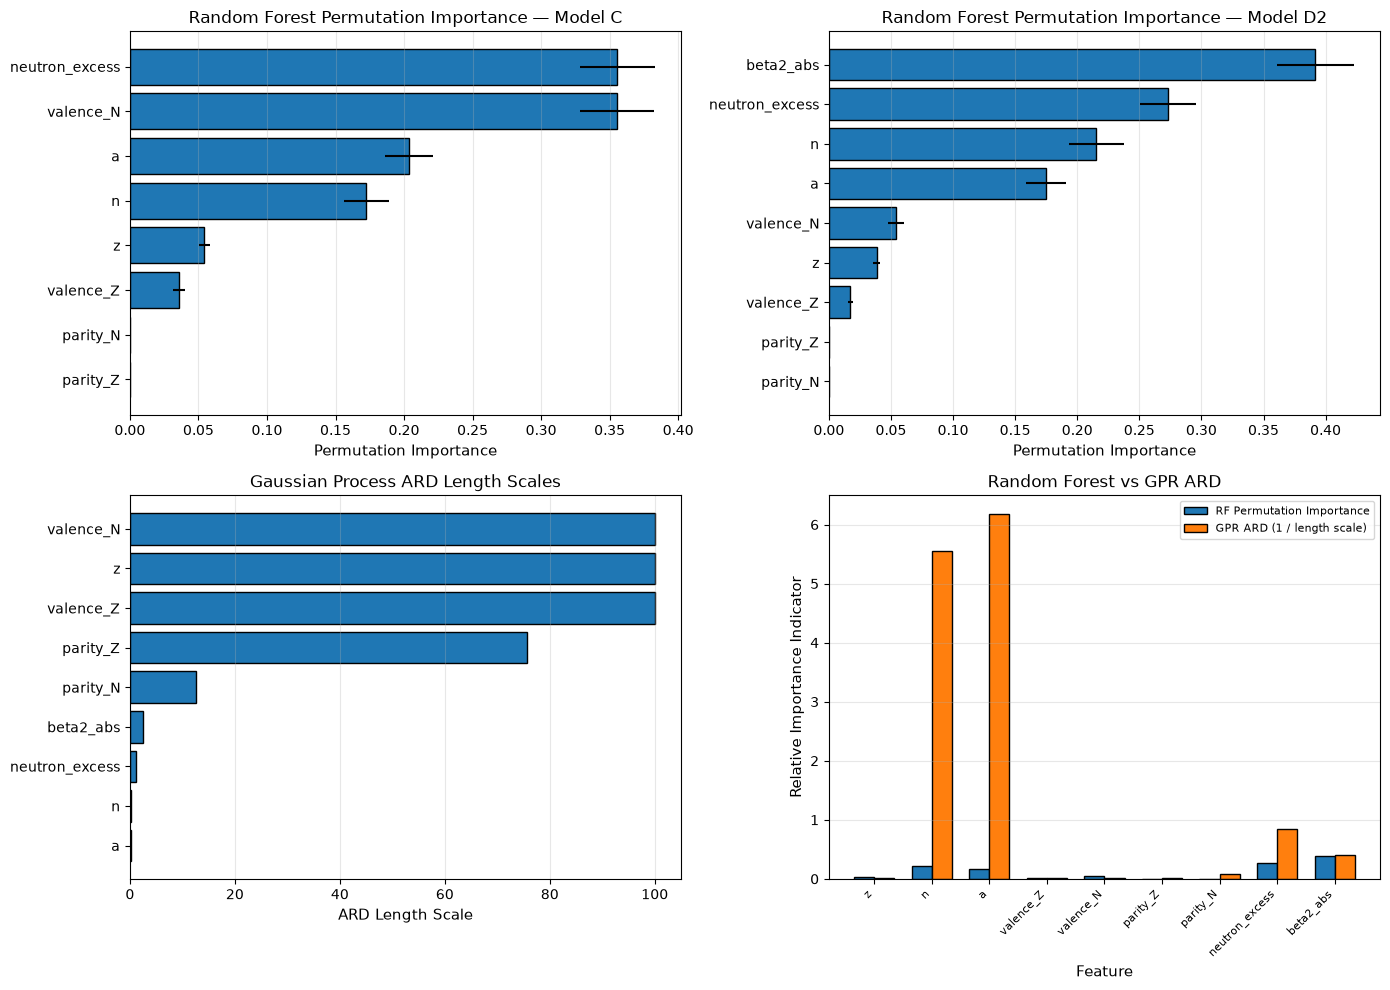


FEATURE IMPORTANCE SUMMARY

Top 3 features — Random Forest (Model C):
  neutron_excess      : 0.3555
  valence_N           : 0.3552
  a                   : 0.2034

Top 3 features — GPR ARD:
  a                   : 1/length scale = 6.1829
  n                   : 1/length scale = 5.5597
  neutron_excess      : 1/length scale = 0.8447

|β₂| Random Forest rank: 1/9
|β₂| GPR ARD rank: 4/9

FEATURE IMPORTANCE ANALYSIS COMPLETED


In [11]:
# ============================================================
# PHASE 5 — FEATURE IMPORTANCE ANALYSIS
# ============================================================
#
# Purpose:
# Evaluate the relative contribution of the engineered features
# using two complementary approaches:
#   1. Random Forest permutation importance
#   2. Gaussian Process ARD length scales
#
# The analysis focuses on Model C (shell features) and
# Model D2 (shell features + experimental |β₂|).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    WhiteKernel,
    ConstantKernel as C
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

TARGET = "residual"

FEATURES_C = [
    "z",
    "n",
    "a",
    "valence_Z",
    "valence_N",
    "parity_Z",
    "parity_N",
    "neutron_excess"
]

FEATURES_D2 = FEATURES_C + ["beta2_abs"]


print("=" * 70)
print("PHASE 5 — FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)


# ============================================================
# 2. PREPARE DATA
# ============================================================

X_C = df_analysis[FEATURES_C].copy()
X_D2 = df_analysis[FEATURES_D2].copy()
y = df_analysis[TARGET].copy()

print(f"\nNumber of nuclei: {len(df_analysis)}")
print(f"Model C features:  {len(FEATURES_C)}")
print(f"Model D2 features: {len(FEATURES_D2)}")


# ============================================================
# 3. RANDOM FOREST PERMUTATION IMPORTANCE
# ============================================================
#
# Permutation importance measures the decrease in model
# performance when the values of one feature are randomly
# permuted.
#
# NOTE:
# This analysis is performed on the available dataset to
# characterize feature usage. It is not used as an estimate
# of generalization performance.
# ============================================================

print("\n" + "=" * 70)
print("RANDOM FOREST PERMUTATION IMPORTANCE")
print("=" * 70)


# ----------------------------
# Model C
# ----------------------------

rf_C = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_C.fit(X_C, y)

perm_C = permutation_importance(
    rf_C,
    X_C,
    y,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_df_C = pd.DataFrame({
    "Feature": FEATURES_C,
    "Importance": perm_C.importances_mean,
    "Std": perm_C.importances_std
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


print("\nModel C — Shell Features")
print("-" * 60)

for _, row in importance_df_C.iterrows():
    print(
        f"{row['Feature']:20s}: "
        f"{row['Importance']:.4f} ± {row['Std']:.4f}"
    )


# ----------------------------
# Model D2
# ----------------------------

rf_D2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_D2.fit(X_D2, y)

perm_D2 = permutation_importance(
    rf_D2,
    X_D2,
    y,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_df_D2 = pd.DataFrame({
    "Feature": FEATURES_D2,
    "Importance": perm_D2.importances_mean,
    "Std": perm_D2.importances_std
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


print("\nModel D2 — Shell Features + |β₂|")
print("-" * 60)

for _, row in importance_df_D2.iterrows():
    print(
        f"{row['Feature']:20s}: "
        f"{row['Importance']:.4f} ± {row['Std']:.4f}"
    )


# Correct β₂ rank calculation
beta2_rank = (
    importance_df_D2.index[
        importance_df_D2["Feature"] == "beta2_abs"
    ][0] + 1
)

print(
    f"\n|β₂| permutation-importance rank: "
    f"{beta2_rank}/{len(FEATURES_D2)}"
)


# ============================================================
# 4. GAUSSIAN PROCESS ARD ANALYSIS
# ============================================================
#
# Automatic Relevance Determination (ARD) assigns an
# independent length scale to each feature.
#
# Smaller length scales generally indicate stronger variation
# of the learned function with respect to that feature.
# Therefore, 1 / length_scale is used only as a comparative
# sensitivity indicator.
# ============================================================

print("\n" + "=" * 70)
print("GAUSSIAN PROCESS — ARD ANALYSIS")
print("=" * 70)

print(
    "\nARD assigns an independent length scale to each feature."
)
print(
    "Smaller length scales indicate stronger model sensitivity "
    "to the corresponding feature."
)


# ARD kernel
kernel_ard = (
    C(1.0)
    * RBF(
        length_scale=np.ones(len(FEATURES_D2)),
        length_scale_bounds=(1e-2, 1e2)
    )
    + WhiteKernel(noise_level=0.1)
)


pipeline_ard = Pipeline([
    ("scaler", StandardScaler()),
    (
        "gpr",
        GaussianProcessRegressor(
            kernel=kernel_ard,
            n_restarts_optimizer=5,
            random_state=42
        )
    )
])


pipeline_ard.fit(X_D2, y)


# Extract optimized kernel
gpr_model = pipeline_ard.named_steps["gpr"]

length_scales = gpr_model.kernel_.k1.k2.length_scale


ard_df = pd.DataFrame({
    "Feature": FEATURES_D2,
    "Length_Scale": length_scales,
    "Inverse_Length_Scale": 1.0 / length_scales
}).sort_values(
    "Length_Scale",
    ascending=True
).reset_index(drop=True)


print("\nOptimized ARD Length Scales")
print("-" * 60)

for _, row in ard_df.iterrows():
    print(
        f"{row['Feature']:20s}: "
        f"length scale = {row['Length_Scale']:.4f}   "
        f"1/length scale = {row['Inverse_Length_Scale']:.4f}"
    )


# Correct β₂ rank calculation
beta2_ard_rank = (
    ard_df.index[
        ard_df["Feature"] == "beta2_abs"
    ][0] + 1
)

print(
    f"\n|β₂| ARD rank: "
    f"{beta2_ard_rank}/{len(FEATURES_D2)}"
)


# ============================================================
# 5. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)


# ------------------------------------------------------------
# Plot 1 — Random Forest permutation importance, Model C
# ------------------------------------------------------------

plot_C = importance_df_C.sort_values(
    "Importance",
    ascending=True
)

axes[0, 0].barh(
    plot_C["Feature"],
    plot_C["Importance"],
    xerr=plot_C["Std"],
    edgecolor="black"
)

axes[0, 0].set_xlabel(
    "Permutation Importance",
    fontsize=11
)

axes[0, 0].set_title(
    "Random Forest Permutation Importance — Model C",
    fontsize=12
)

axes[0, 0].grid(
    True,
    alpha=0.3,
    axis="x"
)


# ------------------------------------------------------------
# Plot 2 — Random Forest permutation importance, Model D2
# ------------------------------------------------------------

plot_D2 = importance_df_D2.sort_values(
    "Importance",
    ascending=True
)

axes[0, 1].barh(
    plot_D2["Feature"],
    plot_D2["Importance"],
    xerr=plot_D2["Std"],
    edgecolor="black"
)

axes[0, 1].set_xlabel(
    "Permutation Importance",
    fontsize=11
)

axes[0, 1].set_title(
    "Random Forest Permutation Importance — Model D2",
    fontsize=12
)

axes[0, 1].grid(
    True,
    alpha=0.3,
    axis="x"
)


# ------------------------------------------------------------
# Plot 3 — GPR ARD length scales
# ------------------------------------------------------------

plot_ard = ard_df.sort_values(
    "Length_Scale",
    ascending=True
)

axes[1, 0].barh(
    plot_ard["Feature"],
    plot_ard["Length_Scale"],
    edgecolor="black"
)

axes[1, 0].set_xlabel(
    "ARD Length Scale",
    fontsize=11
)

axes[1, 0].set_title(
    "Gaussian Process ARD Length Scales",
    fontsize=12
)

axes[1, 0].grid(
    True,
    alpha=0.3,
    axis="x"
)


# ------------------------------------------------------------
# Plot 4 — RF vs GPR comparative importance
# ------------------------------------------------------------
#
# Only features actually present in Model D2 are compared.
# The two quantities have different definitions and are therefore
# shown as relative indicators rather than directly equivalent
# physical importance measures.
# ------------------------------------------------------------

features_common = FEATURES_D2

rf_importance = [
    importance_df_D2.loc[
        importance_df_D2["Feature"] == feature,
        "Importance"
    ].iloc[0]
    for feature in features_common
]

ard_importance = [
    ard_df.loc[
        ard_df["Feature"] == feature,
        "Inverse_Length_Scale"
    ].iloc[0]
    for feature in features_common
]


x_pos = np.arange(len(features_common))
width = 0.35

axes[1, 1].bar(
    x_pos - width / 2,
    rf_importance,
    width,
    label="RF Permutation Importance",
    edgecolor="black"
)

axes[1, 1].bar(
    x_pos + width / 2,
    ard_importance,
    width,
    label="GPR ARD (1 / length scale)",
    edgecolor="black"
)

axes[1, 1].set_xlabel(
    "Feature",
    fontsize=11
)

axes[1, 1].set_ylabel(
    "Relative Importance Indicator",
    fontsize=11
)

axes[1, 1].set_title(
    "Random Forest vs GPR ARD",
    fontsize=12
)

axes[1, 1].set_xticks(x_pos)

axes[1, 1].set_xticklabels(
    features_common,
    rotation=45,
    ha="right",
    fontsize=8
)

axes[1, 1].legend(
    fontsize=8
)

axes[1, 1].grid(
    True,
    alpha=0.3,
    axis="y"
)


plt.tight_layout()
plt.show()


# ============================================================
# 6. SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 70)


# Top three RF features
print("\nTop 3 features — Random Forest (Model C):")

for _, row in importance_df_C.head(3).iterrows():
    print(
        f"  {row['Feature']:20s}: "
        f"{row['Importance']:.4f}"
    )


# Top three ARD features
print("\nTop 3 features — GPR ARD:")

for _, row in ard_df.head(3).iterrows():
    print(
        f"  {row['Feature']:20s}: "
        f"1/length scale = {row['Inverse_Length_Scale']:.4f}"
    )


# β₂ position
print(
    f"\n|β₂| Random Forest rank: "
    f"{beta2_rank}/{len(FEATURES_D2)}"
)

print(
    f"|β₂| GPR ARD rank: "
    f"{beta2_ard_rank}/{len(FEATURES_D2)}"
)


print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS COMPLETED")
print("=" * 70)

PHASE 6 — HYBRID MODEL: FULL PERFORMANCE ANALYSIS
Number of nuclei: 3555
Number of features: 7
Features: ['z', 'n', 'a', 'neutron_excess', 'valence_N', 'magic_dist_N', 'magic_dist_Z']

PHASE 6.3 — SEMF BASELINE
RMSE: 5.5603 MeV
MAE : 3.7655 MeV

PHASE 6.4 — RANDOM FOREST
Fold 1/5 | RMSE = 0.9522 MeV | MAE = 0.4167 MeV
Fold 2/5 | RMSE = 0.5314 MeV | MAE = 0.3284 MeV
Fold 3/5 | RMSE = 0.7586 MeV | MAE = 0.3789 MeV
Fold 4/5 | RMSE = 1.1083 MeV | MAE = 0.4170 MeV
Fold 5/5 | RMSE = 0.7082 MeV | MAE = 0.3738 MeV
----------------------------------------------------------------------
Mean RMSE: 0.8117 ± 0.1999 MeV
Mean MAE : 0.3830 ± 0.0328 MeV
Improvement over SEMF: 85.40%

PHASE 6.4 — EXTRA TREES
Fold 1/5 | RMSE = 0.8695 MeV | MAE = 0.3514 MeV
Fold 2/5 | RMSE = 0.4535 MeV | MAE = 0.2762 MeV
Fold 3/5 | RMSE = 0.6816 MeV | MAE = 0.3273 MeV
Fold 4/5 | RMSE = 1.1338 MeV | MAE = 0.3768 MeV
Fold 5/5 | RMSE = 0.5252 MeV | MAE = 0.3204 MeV
------------------------------------------------------------

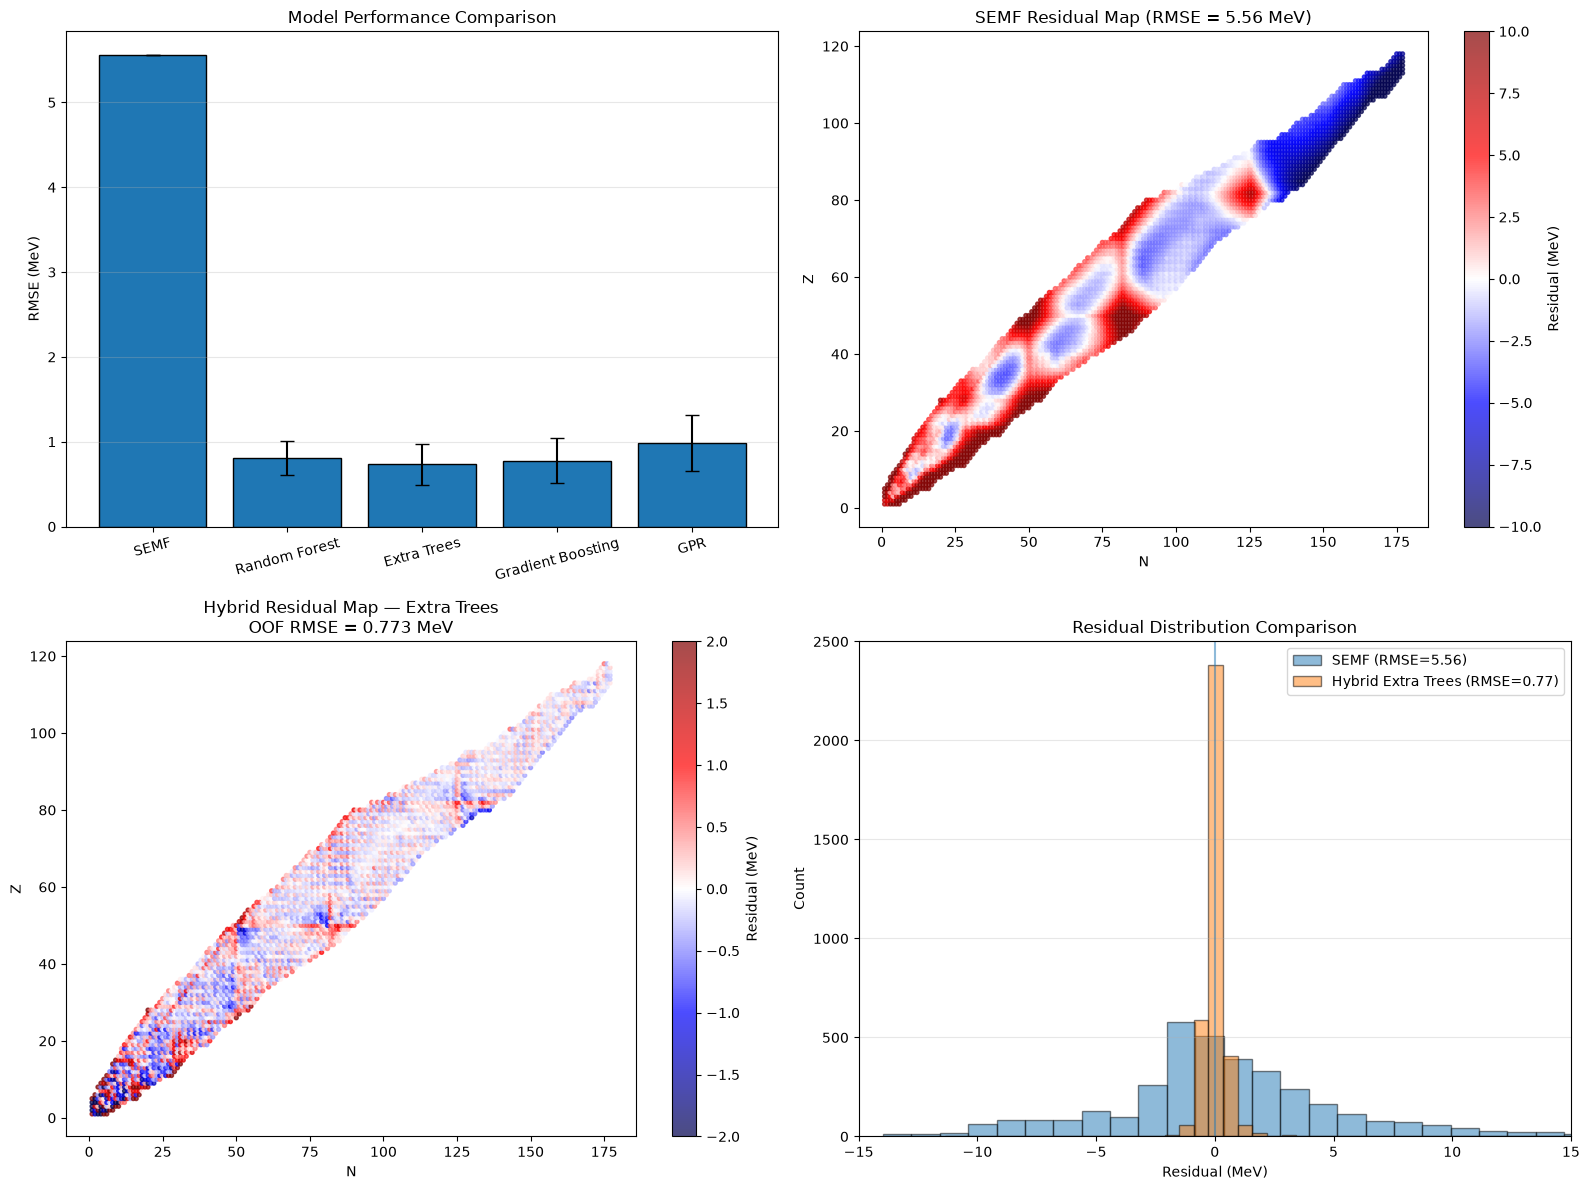


PHASE 6.11 — GPR UNCERTAINTY MAP


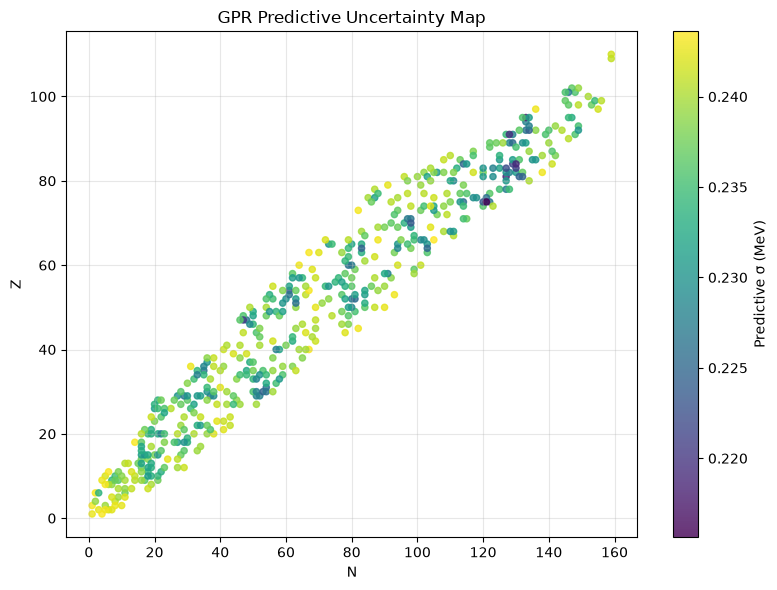


PHASE 6 — FINAL SUMMARY
Dataset size: 3555 nuclei
SEMF RMSE: 5.5603 MeV
Best tree model: Extra Trees
Best tree RMSE: 0.7327 MeV
GPR RMSE: 0.9837 MeV
Hybrid OOF RMSE: 0.7730 MeV
Hybrid OOF MAE: 0.3304 MeV

PHASE 6 — HYBRID MODEL ANALYSIS COMPLETED


In [13]:
# ============================================================
# PHASE 6 — HYBRID MODEL: FULL PERFORMANCE ANALYSIS
# ============================================================
#
# Purpose:
# This phase evaluates the hybrid nuclear mass model on the
# complete AME2020 dataset.
#
# The workflow consists of:
#   1. Full-dataset feature engineering
#   2. SEMF baseline evaluation
#   3. Tree-based residual correction models
#   4. Balanced-sample Gaussian Process Regression
#   5. Cross-validated model comparison
#   6. Out-of-fold hybrid residual analysis
#   7. Residual maps and distributions
#   8. GPR uncertainty visualization
#
# Important:
# All reported predictive performance is based on cross-validation
# or out-of-fold predictions to avoid evaluating the model on the
# same nuclei used for training.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    WhiteKernel,
    ConstantKernel as C
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# PHASE 6.1 — FULL DATASET PREPARATION
# ============================================================
#
# The complete AME2020 dataset is used for the tree-based models.
# The target variable is the SEMF residual:
#
#     residual = experimental binding energy - SEMF prediction
#
# The machine-learning models therefore learn corrections to the
# baseline SEMF rather than predicting the nuclear binding energy
# directly.
# ============================================================

df_full = df_ame.copy()

MAGIC_NUMBERS = np.array([2, 8, 20, 28, 50, 82, 126])


def get_min_magic_dist(value):
    """Return the distance to the nearest magic number."""
    return np.min(np.abs(MAGIC_NUMBERS - value))


def get_signed_magic_dist(value):
    """Return the signed distance from the nearest magic number."""
    nearest = MAGIC_NUMBERS[np.argmin(np.abs(MAGIC_NUMBERS - value))]
    return value - nearest


# Shell-structure features
df_full["magic_dist_Z"] = df_full["z"].apply(get_min_magic_dist)
df_full["magic_dist_N"] = df_full["n"].apply(get_min_magic_dist)

df_full["valence_Z"] = df_full["z"].apply(get_signed_magic_dist)
df_full["valence_N"] = df_full["n"].apply(get_signed_magic_dist)

# Pairing/parity information
df_full["parity_Z"] = df_full["z"] % 2
df_full["parity_N"] = df_full["n"] % 2

# Isospin-related feature
df_full["neutron_excess"] = (
    (df_full["n"] - df_full["z"]) / df_full["a"]
)

# Remove unphysical entries
df_full = df_full[
    (df_full["n"] > 0) &
    (df_full["z"] > 0) &
    (df_full["a"] > 0)
].copy()


# ============================================================
# PHASE 6.2 — OPTIMAL FEATURE SET
# ============================================================
#
# The feature set was selected from the previous feature-importance
# analysis. It combines:
#
#   - proton number
#   - neutron number
#   - mass number
#   - neutron excess
#   - neutron valence distance
#   - neutron shell distance
#   - proton shell distance
#
# No deformation variable is used here because the full AME2020
# dataset does not contain experimental Raman β₂ values for every
# nucleus.
# ============================================================

TARGET = "residual"

FEATURES_OPTIMAL = [
    "z",
    "n",
    "a",
    "neutron_excess",
    "valence_N",
    "magic_dist_N",
    "magic_dist_Z",
]

KF = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("=" * 70)
print("PHASE 6 — HYBRID MODEL: FULL PERFORMANCE ANALYSIS")
print("=" * 70)

print(f"Number of nuclei: {len(df_full)}")
print(f"Number of features: {len(FEATURES_OPTIMAL)}")
print(f"Features: {FEATURES_OPTIMAL}")


# ============================================================
# PHASE 6.3 — SEMF BASELINE
# ============================================================
#
# SEMF is treated as the physical baseline.
#
# The ML models do not replace SEMF. Instead, they learn the
# residual structure that remains after the macroscopic SEMF
# prediction.
# ============================================================

semf_rmse = root_mean_squared_error(
    df_full[TARGET],
    np.zeros(len(df_full))
)

semf_mae = mean_absolute_error(
    df_full[TARGET],
    np.zeros(len(df_full))
)

print("\n" + "=" * 70)
print("PHASE 6.3 — SEMF BASELINE")
print("=" * 70)

print(f"RMSE: {semf_rmse:.4f} MeV")
print(f"MAE : {semf_mae:.4f} MeV")


# ============================================================
# PHASE 6.4 — TREE-BASED RESIDUAL MODELS
# ============================================================
#
# Three nonlinear regressors are evaluated:
#
#   1. Random Forest
#   2. Extra Trees
#   3. Gradient Boosting
#
# Each model is evaluated using identical 5-fold cross-validation.
# ============================================================

MODELS = {
    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": lambda: ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": lambda: GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    ),
}


tree_results = {}

for model_name, model_factory in MODELS.items():

    print("\n" + "=" * 70)
    print(f"PHASE 6.4 — {model_name.upper()}")
    print("=" * 70)

    rmse_scores = []
    mae_scores = []

    for fold, (train_idx, test_idx) in enumerate(
        KF.split(df_full), start=1
    ):

        train = df_full.iloc[train_idx]
        test = df_full.iloc[test_idx]

        model = model_factory()

        model.fit(
            train[FEATURES_OPTIMAL],
            train[TARGET]
        )

        prediction = model.predict(
            test[FEATURES_OPTIMAL]
        )

        rmse = root_mean_squared_error(
            test[TARGET],
            prediction
        )

        mae = mean_absolute_error(
            test[TARGET],
            prediction
        )

        rmse_scores.append(rmse)
        mae_scores.append(mae)

        print(
            f"Fold {fold}/5 | "
            f"RMSE = {rmse:.4f} MeV | "
            f"MAE = {mae:.4f} MeV"
        )

    rmse_mean = np.mean(rmse_scores)
    rmse_std = np.std(rmse_scores)

    mae_mean = np.mean(mae_scores)
    mae_std = np.std(mae_scores)

    improvement = (
        (semf_rmse - rmse_mean) /
        semf_rmse *
        100
    )

    tree_results[model_name] = {
        "RMSE_mean": rmse_mean,
        "RMSE_std": rmse_std,
        "MAE_mean": mae_mean,
        "MAE_std": mae_std,
        "RMSE_folds": rmse_scores,
    }

    print("-" * 70)
    print(
        f"Mean RMSE: {rmse_mean:.4f} ± "
        f"{rmse_std:.4f} MeV"
    )
    print(
        f"Mean MAE : {mae_mean:.4f} ± "
        f"{mae_std:.4f} MeV"
    )
    print(
        f"Improvement over SEMF: "
        f"{improvement:.2f}%"
    )


# ============================================================
# PHASE 6.5 — BALANCED GPR SAMPLE
# ============================================================
#
# Gaussian Process Regression has substantially higher computational
# cost than tree-based models. Therefore, a balanced subset is used.
#
# The sample is stratified according to the total distance from
# proton and neutron magic numbers.
#
# This prevents the GPR analysis from being dominated by one
# structural region of the nuclear chart.
# ============================================================

print("\n" + "=" * 70)
print("PHASE 6.5 — BALANCED GPR SAMPLE")
print("=" * 70)

df_full["total_magic_dist"] = (
    df_full["magic_dist_Z"] +
    df_full["magic_dist_N"]
)

df_full["magic_group"] = pd.cut(
    df_full["total_magic_dist"],
    bins=[0, 2, 5, 10, 20, 50],
    labels=[
        "Very Close",
        "Close",
        "Medium",
        "Far",
        "Very Far"
    ]
)

TARGET_PER_GROUP = {
    "Very Close": 50,
    "Close": 80,
    "Medium": 120,
    "Far": 150,
    "Very Far": 100,
}

gpr_samples = []

for group, target_size in TARGET_PER_GROUP.items():

    group_data = df_full[
        df_full["magic_group"] == group
    ]

    sample_size = min(
        target_size,
        len(group_data)
    )

    if sample_size > 0:
        gpr_samples.append(
            group_data.sample(
                sample_size,
                random_state=42
            )
        )

df_gpr = pd.concat(
    gpr_samples,
    ignore_index=True
)

print(f"GPR sample size: {len(df_gpr)} nuclei")
print(
    "Group distribution:"
)
print(
    df_gpr["magic_group"]
    .value_counts()
    .sort_index()
)


# ============================================================
# PHASE 6.6 — GAUSSIAN PROCESS REGRESSION
# ============================================================
#
# A Matérn kernel is used because it allows a less restrictive
# smoothness assumption than the RBF kernel.
#
# Standardization is applied before GPR because the input
# variables have very different numerical scales.
#
# Five-fold cross-validation is used to obtain an independent
# estimate of predictive performance.
# ============================================================

print("\n" + "=" * 70)
print("PHASE 6.6 — GAUSSIAN PROCESS REGRESSION")
print("=" * 70)

GPR_KERNEL = (
    C(1.0)
    * Matern(
        length_scale=1.0,
        nu=1.5
    )
    + WhiteKernel(
        noise_level=0.1
    )
)

gpr_rmse = []
gpr_mae = []
gpr_uncertainty = []

for fold, (train_idx, test_idx) in enumerate(
    KF.split(df_gpr),
    start=1
):

    train = df_gpr.iloc[train_idx]
    test = df_gpr.iloc[test_idx]

    gpr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        (
            "gpr",
            GaussianProcessRegressor(
                kernel=GPR_KERNEL,
                n_restarts_optimizer=3,
                random_state=42
            )
        )
    ])

    gpr_pipeline.fit(
        train[FEATURES_OPTIMAL],
        train[TARGET]
    )

    prediction, uncertainty = (
        gpr_pipeline.predict(
            test[FEATURES_OPTIMAL],
            return_std=True
        )
    )

    rmse = root_mean_squared_error(
        test[TARGET],
        prediction
    )

    mae = mean_absolute_error(
        test[TARGET],
        prediction
    )

    mean_uncertainty = np.mean(
        uncertainty
    )

    gpr_rmse.append(rmse)
    gpr_mae.append(mae)
    gpr_uncertainty.append(
        mean_uncertainty
    )

    print(
        f"Fold {fold}/5 | "
        f"RMSE = {rmse:.4f} MeV | "
        f"MAE = {mae:.4f} MeV | "
        f"Mean σ = {mean_uncertainty:.4f} MeV"
    )


gpr_results = {
    "RMSE_mean": np.mean(gpr_rmse),
    "RMSE_std": np.std(gpr_rmse),
    "MAE_mean": np.mean(gpr_mae),
    "MAE_std": np.std(gpr_mae),
    "Std_mean": np.mean(gpr_uncertainty),
}


print("-" * 70)
print(
    f"Mean RMSE: "
    f"{gpr_results['RMSE_mean']:.4f} ± "
    f"{gpr_results['RMSE_std']:.4f} MeV"
)

print(
    f"Mean MAE : "
    f"{gpr_results['MAE_mean']:.4f} ± "
    f"{gpr_results['MAE_std']:.4f} MeV"
)

print(
    f"Mean predictive σ: "
    f"{gpr_results['Std_mean']:.4f} MeV"
)


# ============================================================
# PHASE 6.7 — MODEL COMPARISON
# ============================================================

all_results = {
    **tree_results,
    "GPR": gpr_results
}

print("\n" + "=" * 70)
print("PHASE 6.7 — MODEL COMPARISON")
print("=" * 70)

print(
    f"{'Model':20s} | "
    f"{'RMSE (MeV)':>12s} | "
    f"{'MAE (MeV)':>12s} | "
    f"{'Improvement':>12s}"
)

print("-" * 70)

print(
    f"{'SEMF':20s} | "
    f"{semf_rmse:12.4f} | "
    f"{semf_mae:12.4f} | "
    f"{'Baseline':>12s}"
)

for name, result in all_results.items():

    improvement = (
        (semf_rmse - result["RMSE_mean"])
        / semf_rmse
        * 100
    )

    print(
        f"{name:20s} | "
        f"{result['RMSE_mean']:12.4f} | "
        f"{result['MAE_mean']:12.4f} | "
        f"{improvement:11.2f}%"
    )


best_model_name = min(
    all_results,
    key=lambda name:
    all_results[name]["RMSE_mean"]
)

print("\nBest predictive model:")
print(f"  {best_model_name}")
print(
    f"  RMSE = "
    f"{all_results[best_model_name]['RMSE_mean']:.4f} MeV"
)


# ============================================================
# PHASE 6.8 — OUT-OF-FOLD HYBRID RESIDUAL ANALYSIS
# ============================================================
#
# The best tree-based model is retrained within each fold.
# Predictions are stored only for the corresponding held-out
# nuclei.
#
# This produces a genuine out-of-fold hybrid residual:
#
#     hybrid residual =
#     SEMF residual - ML-predicted residual
#
# Therefore, the resulting map does not contain training-set
# predictions.
# ============================================================

best_tree = min(
    tree_results,
    key=lambda name:
    tree_results[name]["RMSE_mean"]
)

print("\n" + "=" * 70)
print("PHASE 6.8 — OUT-OF-FOLD HYBRID ANALYSIS")
print("=" * 70)

print(f"Selected tree model: {best_tree}")

oof_prediction = np.zeros(
    len(df_full)
)

for train_idx, test_idx in KF.split(df_full):

    train = df_full.iloc[train_idx]
    test = df_full.iloc[test_idx]

    model = MODELS[best_tree]()

    model.fit(
        train[FEATURES_OPTIMAL],
        train[TARGET]
    )

    oof_prediction[test_idx] = (
        model.predict(
            test[FEATURES_OPTIMAL]
        )
    )


df_full["hybrid_residual"] = (
    df_full[TARGET].values -
    oof_prediction
)

hybrid_rmse = root_mean_squared_error(
    df_full[TARGET],
    oof_prediction
)

hybrid_mae = mean_absolute_error(
    df_full[TARGET],
    oof_prediction
)

print(f"OOF hybrid RMSE: {hybrid_rmse:.4f} MeV")
print(f"OOF hybrid MAE : {hybrid_mae:.4f} MeV")


# ============================================================
# PHASE 6.9 — HYBRID RESIDUAL STATISTICS
# ============================================================

hybrid_residual = df_full["hybrid_residual"]

print("\n" + "=" * 70)
print("PHASE 6.9 — HYBRID RESIDUAL STATISTICS")
print("=" * 70)

print(
    f"RMS: "
    f"{np.sqrt(np.mean(hybrid_residual**2)):.4f} MeV"
)

print(
    f"Standard deviation: "
    f"{np.std(hybrid_residual):.4f} MeV"
)

print(
    f"Minimum: "
    f"{hybrid_residual.min():.4f} MeV"
)

print(
    f"Maximum: "
    f"{hybrid_residual.max():.4f} MeV"
)

print(
    f"95% interval: "
    f"[{np.percentile(hybrid_residual, 2.5):.2f}, "
    f"{np.percentile(hybrid_residual, 97.5):.2f}] MeV"
)

for threshold in [0.5, 1.0, 2.0]:

    count = (
        np.abs(hybrid_residual)
        < threshold
    ).sum()

    percentage = (
        count /
        len(hybrid_residual) *
        100
    )

    print(
        f"|residual| < {threshold:.1f} MeV: "
        f"{count} ({percentage:.1f}%)"
    )

count_large = (
    np.abs(hybrid_residual) > 3.0
).sum()

percentage_large = (
    count_large /
    len(hybrid_residual) *
    100
)

print(
    f"|residual| > 3.0 MeV: "
    f"{count_large} ({percentage_large:.1f}%)"
)


# ============================================================
# PHASE 6.10 — PERFORMANCE VISUALIZATION
# ============================================================

print("\n" + "=" * 70)
print("PHASE 6.10 — PERFORMANCE VISUALIZATION")
print("=" * 70)

model_names = [
    "SEMF",
    *all_results.keys()
]

rmse_values = [
    semf_rmse,
    *[
        all_results[name]["RMSE_mean"]
        for name in all_results
    ]
]

rmse_errors = [
    0,
    *[
        all_results[name]["RMSE_std"]
        for name in all_results
    ]
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)


# --- Model comparison ---
axes[0, 0].bar(
    model_names,
    rmse_values,
    yerr=rmse_errors,
    edgecolor="black",
    capsize=5
)

axes[0, 0].set_ylabel(
    "RMSE (MeV)"
)

axes[0, 0].set_title(
    "Model Performance Comparison"
)

axes[0, 0].tick_params(
    axis="x",
    rotation=15
)

axes[0, 0].grid(
    True,
    alpha=0.3,
    axis="y"
)


# --- SEMF residual map ---
semf_limit = 10

scatter_semf = axes[0, 1].scatter(
    df_full["n"],
    df_full["z"],
    c=df_full["residual"],
    cmap="seismic",
    vmin=-semf_limit,
    vmax=semf_limit,
    s=8,
    alpha=0.7
)

axes[0, 1].set_xlabel("N")
axes[0, 1].set_ylabel("Z")

axes[0, 1].set_title(
    f"SEMF Residual Map "
    f"(RMSE = {semf_rmse:.2f} MeV)"
)

plt.colorbar(
    scatter_semf,
    ax=axes[0, 1],
    label="Residual (MeV)"
)


# --- Hybrid residual map ---
hybrid_limit = 2.0

scatter_hybrid = axes[1, 0].scatter(
    df_full["n"],
    df_full["z"],
    c=df_full["hybrid_residual"],
    cmap="seismic",
    vmin=-hybrid_limit,
    vmax=hybrid_limit,
    s=8,
    alpha=0.7
)

axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel("Z")

axes[1, 0].set_title(
    f"Hybrid Residual Map — {best_tree}\n"
    f"OOF RMSE = {hybrid_rmse:.3f} MeV"
)

plt.colorbar(
    scatter_hybrid,
    ax=axes[1, 0],
    label="Residual (MeV)"
)


# --- Residual distribution ---
axes[1, 1].hist(
    df_full["residual"],
    bins=50,
    alpha=0.5,
    label=f"SEMF (RMSE={semf_rmse:.2f})",
    edgecolor="black"
)

axes[1, 1].hist(
    df_full["hybrid_residual"],
    bins=50,
    alpha=0.5,
    label=f"Hybrid {best_tree} "
          f"(RMSE={hybrid_rmse:.2f})",
    edgecolor="black"
)

axes[1, 1].axvline(
    0,
    linestyle="-",
    alpha=0.5
)

axes[1, 1].set_xlabel(
    "Residual (MeV)"
)

axes[1, 1].set_ylabel(
    "Count"
)

axes[1, 1].set_title(
    "Residual Distribution Comparison"
)

axes[1, 1].legend()

axes[1, 1].set_xlim(
    -15,
    15
)

axes[1, 1].grid(
    True,
    alpha=0.3,
    axis="y"
)

plt.tight_layout()
plt.show()


# ============================================================
# PHASE 6.11 — GPR UNCERTAINTY MAP
# ============================================================
#
# The GPR is finally trained on the balanced sample to visualize
# its predictive uncertainty across the N-Z plane.
#
# This map is exploratory because the GPR was trained on the
# balanced subset rather than the complete AME2020 dataset.
# ============================================================

print("\n" + "=" * 70)
print("PHASE 6.11 — GPR UNCERTAINTY MAP")
print("=" * 70)

gpr_full_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "gpr",
        GaussianProcessRegressor(
            kernel=GPR_KERNEL,
            n_restarts_optimizer=3,
            random_state=42
        )
    )
])

gpr_full_pipeline.fit(
    df_gpr[FEATURES_OPTIMAL],
    df_gpr[TARGET]
)

gpr_prediction, gpr_std = (
    gpr_full_pipeline.predict(
        df_gpr[FEATURES_OPTIMAL],
        return_std=True
    )
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

scatter_gpr = ax.scatter(
    df_gpr["n"],
    df_gpr["z"],
    c=gpr_std,
    cmap="viridis",
    s=20,
    alpha=0.8
)

ax.set_xlabel("N")
ax.set_ylabel("Z")

ax.set_title(
    "GPR Predictive Uncertainty Map"
)

plt.colorbar(
    scatter_gpr,
    ax=ax,
    label="Predictive σ (MeV)"
)

ax.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# PHASE 6.12 — FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PHASE 6 — FINAL SUMMARY")
print("=" * 70)

print(f"Dataset size: {len(df_full)} nuclei")
print(f"SEMF RMSE: {semf_rmse:.4f} MeV")
print(f"Best tree model: {best_tree}")
print(f"Best tree RMSE: {tree_results[best_tree]['RMSE_mean']:.4f} MeV")
print(f"GPR RMSE: {gpr_results['RMSE_mean']:.4f} MeV")
print(f"Hybrid OOF RMSE: {hybrid_rmse:.4f} MeV")
print(f"Hybrid OOF MAE: {hybrid_mae:.4f} MeV")

print("\n" + "=" * 70)
print("PHASE 6 — HYBRID MODEL ANALYSIS COMPLETED")
print("=" * 70)

PHASE 7 — CRITICAL ROLE OF MAGIC-NUMBER FEATURES

Running 5-fold cross-validation...

Geometry (Z,N,A)
------------------------------------------------------------
Mean RMSE: 0.9417 ± 0.3327 MeV

Geometry + Basic
------------------------------------------------------------
Mean RMSE: 0.7164 ± 0.2676 MeV

Full Model (+Shell)
------------------------------------------------------------
Mean RMSE: 0.7327 ± 0.2463 MeV

PHASE 7.3 — FEATURE-GROUP CONTRIBUTION ANALYSIS

SEMF baseline RMSE : 5.5603 MeV
Geometry model     : 0.9417 MeV
Basic model        : 0.7164 MeV
Full shell model   : 0.7327 MeV

Incremental improvements:
SEMF → Geometry : +4.6186 MeV
Geometry → Basic: +0.2253 MeV
Basic → Shell   : -0.0164 MeV

PHASE 7.4 — OUT-OF-FOLD RESIDUAL ANALYSIS

OOF RMSE:
Geometry model    : 0.9987 MeV
Basic model       : 0.7647 MeV
Full shell model  : 0.7730 MeV

PHASE 7.6 — VISUALIZATION


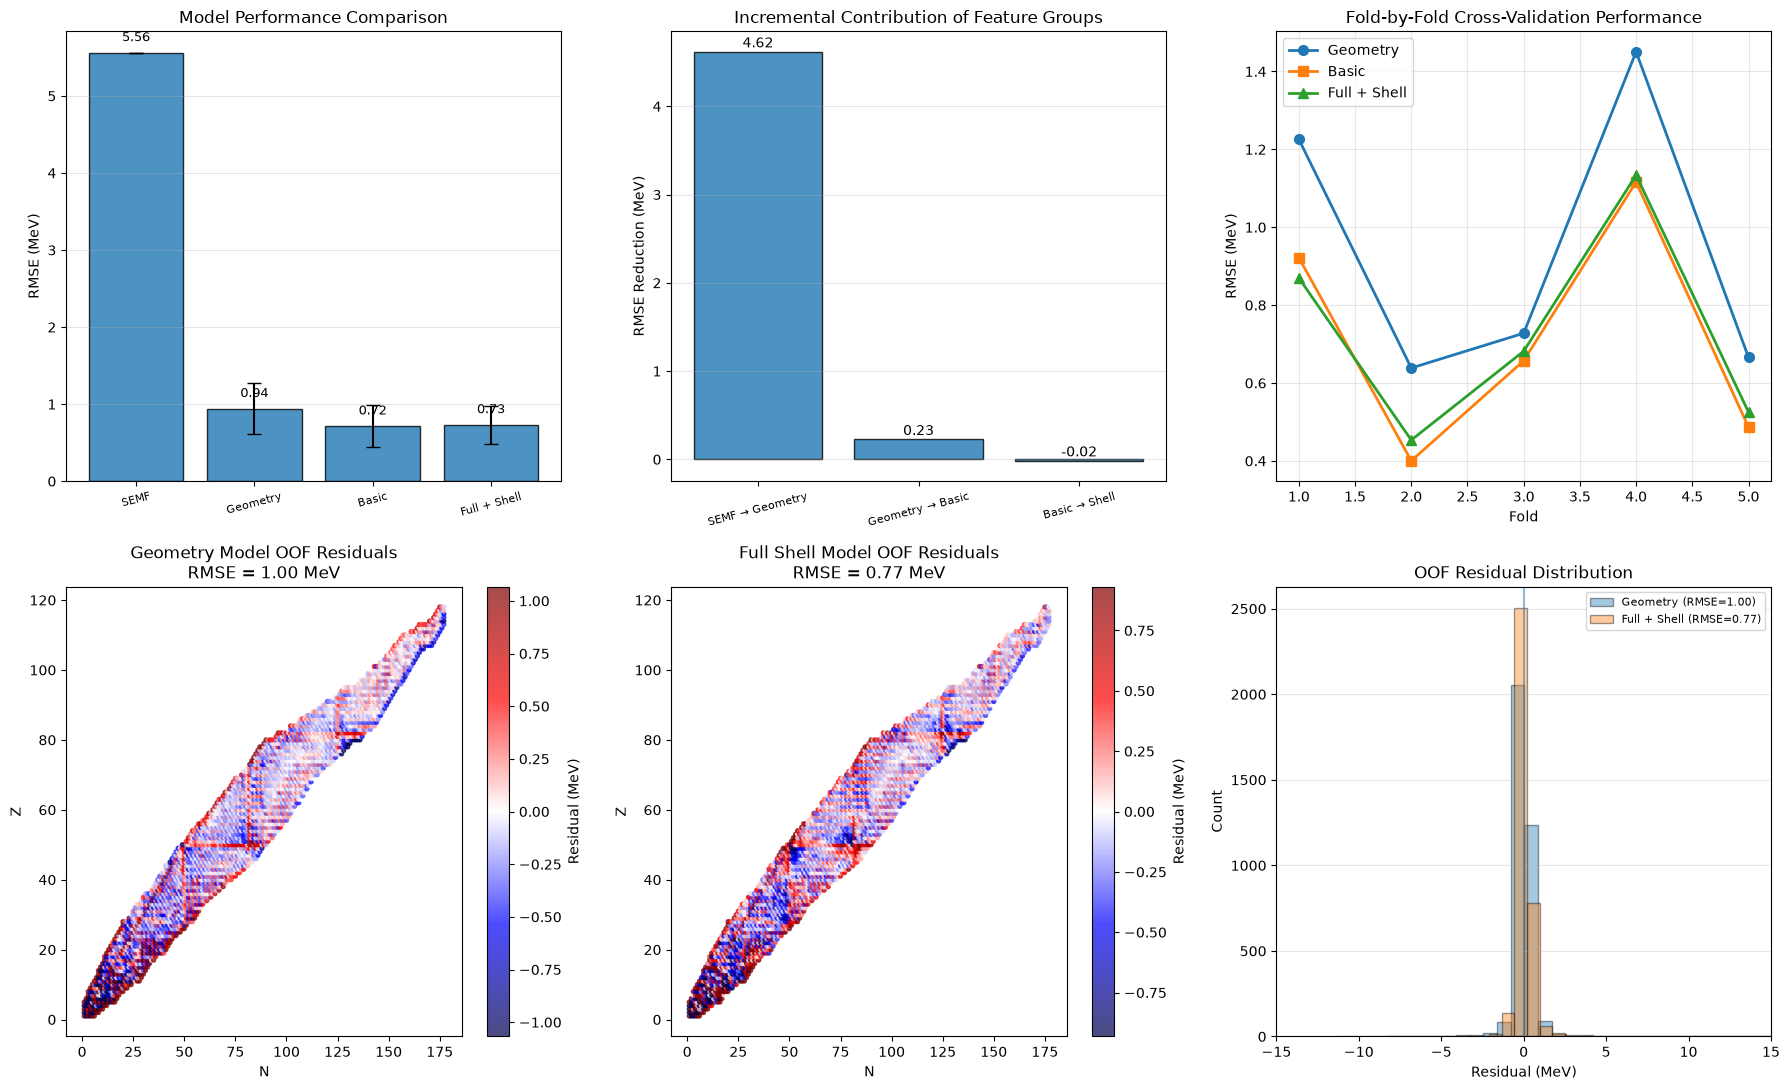


PHASE 7 — FINAL SUMMARY

Dataset size: 3555 nuclei

SEMF baseline RMSE:
    5.5603 MeV

Geometry model RMSE:
    0.9417 ± 0.3327 MeV

Geometry + Basic model RMSE:
    0.7164 ± 0.2676 MeV

Full Shell model RMSE:
    0.7327 ± 0.2463 MeV

Incremental shell contribution:
    -0.0164 MeV

OOF Full Shell RMSE:
    0.7730 MeV


PHASE 7 — MAGIC-NUMBER ANALYSIS COMPLETED


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

warnings.filterwarnings("ignore")


# ======================================================================
# PHASE 7 — CRITICAL ROLE OF MAGIC-NUMBER FEATURES
# ======================================================================

print("=" * 70)
print("PHASE 7 — CRITICAL ROLE OF MAGIC-NUMBER FEATURES")
print("=" * 70)

target = "residual"

# ----------------------------------------------------------------------
# 7.1 MODEL DEFINITIONS
# ----------------------------------------------------------------------
# Three nested feature sets are compared:
#
# Model 1: Geometric information only
# Model 2: Geometry + basic nuclear descriptors
# Model 3: Full model including shell-related features
#
# The goal is to isolate the contribution of shell-related information
# to the prediction of SEMF residuals.

features_geometry = [
    "z",
    "n",
    "a"
]

features_basic = [
    "z",
    "n",
    "a",
    "neutron_excess",
    "parity_Z",
    "parity_N"
]

features_full = [
    "z",
    "n",
    "a",
    "neutron_excess",
    "valence_N",
    "magic_dist_N",
    "magic_dist_Z"
]

models = {
    "Geometry (Z,N,A)": features_geometry,
    "Geometry + Basic": features_basic,
    "Full Model (+Shell)": features_full,
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}


# ----------------------------------------------------------------------
# 7.2 CROSS-VALIDATION PERFORMANCE
# ----------------------------------------------------------------------

print("\nRunning 5-fold cross-validation...\n")

for model_name, features in models.items():

    rmse_folds = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df_full)):

        train_data = df_full.iloc[train_idx]
        test_data = df_full.iloc[test_idx]

        model = ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            train_data[features],
            train_data[target]
        )

        y_pred = model.predict(
            test_data[features]
        )

        rmse = root_mean_squared_error(
            test_data[target],
            y_pred
        )

        rmse_folds.append(rmse)

    results[model_name] = {
        "RMSE_mean": np.mean(rmse_folds),
        "RMSE_std": np.std(rmse_folds),
        "RMSE_folds": rmse_folds
    }

    print(model_name)
    print("-" * 60)
    print(
        f"Mean RMSE: "
        f"{results[model_name]['RMSE_mean']:.4f} "
        f"± {results[model_name]['RMSE_std']:.4f} MeV"
    )
    print()


# ----------------------------------------------------------------------
# 7.3 FEATURE-GROUP CONTRIBUTION ANALYSIS
# ----------------------------------------------------------------------

print("=" * 70)
print("PHASE 7.3 — FEATURE-GROUP CONTRIBUTION ANALYSIS")
print("=" * 70)

semf_rmse = np.sqrt(
    np.mean(df_full[target] ** 2)
)

rmse_geometry = results["Geometry (Z,N,A)"]["RMSE_mean"]
rmse_basic = results["Geometry + Basic"]["RMSE_mean"]
rmse_full = results["Full Model (+Shell)"]["RMSE_mean"]

geometry_gain = semf_rmse - rmse_geometry
basic_gain = rmse_geometry - rmse_basic
shell_gain = rmse_basic - rmse_full

print(f"\nSEMF baseline RMSE : {semf_rmse:.4f} MeV")
print(f"Geometry model     : {rmse_geometry:.4f} MeV")
print(f"Basic model        : {rmse_basic:.4f} MeV")
print(f"Full shell model   : {rmse_full:.4f} MeV")

print("\nIncremental improvements:")
print(f"SEMF → Geometry : {geometry_gain:+.4f} MeV")
print(f"Geometry → Basic: {basic_gain:+.4f} MeV")
print(f"Basic → Shell   : {shell_gain:+.4f} MeV")


# ----------------------------------------------------------------------
# 7.4 OUT-OF-FOLD PREDICTIONS
# ----------------------------------------------------------------------
# Out-of-fold predictions are generated so that residual maps and
# residual distributions are evaluated without using the corresponding
# test nuclei during training.

print("\n" + "=" * 70)
print("PHASE 7.4 — OUT-OF-FOLD RESIDUAL ANALYSIS")
print("=" * 70)

oof_predictions = {}

for model_name, features in models.items():

    oof_pred = np.zeros(len(df_full))

    for train_idx, test_idx in kf.split(df_full):

        train_data = df_full.iloc[train_idx]
        test_data = df_full.iloc[test_idx]

        model = ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            train_data[features],
            train_data[target]
        )

        oof_pred[test_idx] = model.predict(
            test_data[features]
        )

    oof_predictions[model_name] = oof_pred


df_full["residual_geometry"] = (
    df_full[target].values
    - oof_predictions["Geometry (Z,N,A)"]
)

df_full["residual_basic"] = (
    df_full[target].values
    - oof_predictions["Geometry + Basic"]
)

df_full["residual_full"] = (
    df_full[target].values
    - oof_predictions["Full Model (+Shell)"]
)


# ----------------------------------------------------------------------
# 7.5 OOF PERFORMANCE CHECK
# ----------------------------------------------------------------------

rmse_oof_geometry = np.sqrt(
    np.mean(df_full["residual_geometry"] ** 2)
)

rmse_oof_basic = np.sqrt(
    np.mean(df_full["residual_basic"] ** 2)
)

rmse_oof_full = np.sqrt(
    np.mean(df_full["residual_full"] ** 2)
)

print("\nOOF RMSE:")
print(f"Geometry model    : {rmse_oof_geometry:.4f} MeV")
print(f"Basic model       : {rmse_oof_basic:.4f} MeV")
print(f"Full shell model  : {rmse_oof_full:.4f} MeV")


# ----------------------------------------------------------------------
# 7.6 VISUALIZATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 7.6 — VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11)
)


# ----------------------------------------------------------------------
# Plot 1 — Model Performance
# ----------------------------------------------------------------------

model_names = [
    "SEMF",
    "Geometry",
    "Basic",
    "Full + Shell"
]

rmse_values = [
    semf_rmse,
    results["Geometry (Z,N,A)"]["RMSE_mean"],
    results["Geometry + Basic"]["RMSE_mean"],
    results["Full Model (+Shell)"]["RMSE_mean"]
]

rmse_errors = [
    0,
    results["Geometry (Z,N,A)"]["RMSE_std"],
    results["Geometry + Basic"]["RMSE_std"],
    results["Full Model (+Shell)"]["RMSE_std"]
]

axes[0, 0].bar(
    model_names,
    rmse_values,
    yerr=rmse_errors,
    edgecolor="black",
    capsize=5,
    alpha=0.8
)

axes[0, 0].set_ylabel("RMSE (MeV)")
axes[0, 0].set_title(
    "Model Performance Comparison"
)
axes[0, 0].tick_params(
    axis="x",
    rotation=15,
    labelsize=8
)
axes[0, 0].grid(
    True,
    alpha=0.3,
    axis="y"
)

for i, value in enumerate(rmse_values):
    axes[0, 0].text(
        i,
        value + 0.15,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )


# ----------------------------------------------------------------------
# Plot 2 — Incremental Contribution
# ----------------------------------------------------------------------

contribution_labels = [
    "SEMF → Geometry",
    "Geometry → Basic",
    "Basic → Shell"
]

contribution_values = [
    geometry_gain,
    basic_gain,
    shell_gain
]

axes[0, 1].bar(
    contribution_labels,
    contribution_values,
    edgecolor="black",
    alpha=0.8
)

axes[0, 1].set_ylabel(
    "RMSE Reduction (MeV)"
)

axes[0, 1].set_title(
    "Incremental Contribution of Feature Groups"
)

axes[0, 1].tick_params(
    axis="x",
    rotation=15,
    labelsize=8
)

axes[0, 1].grid(
    True,
    alpha=0.3,
    axis="y"
)

for i, value in enumerate(contribution_values):
    axes[0, 1].text(
        i,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )


# ----------------------------------------------------------------------
# Plot 3 — Fold-by-Fold Performance
# ----------------------------------------------------------------------

folds = np.arange(1, 6)

axes[0, 2].plot(
    folds,
    results["Geometry (Z,N,A)"]["RMSE_folds"],
    "o-",
    label="Geometry",
    linewidth=2,
    markersize=7
)

axes[0, 2].plot(
    folds,
    results["Geometry + Basic"]["RMSE_folds"],
    "s-",
    label="Basic",
    linewidth=2,
    markersize=7
)

axes[0, 2].plot(
    folds,
    results["Full Model (+Shell)"]["RMSE_folds"],
    "^-",
    label="Full + Shell",
    linewidth=2,
    markersize=7
)

axes[0, 2].set_xlabel("Fold")
axes[0, 2].set_ylabel("RMSE (MeV)")
axes[0, 2].set_title(
    "Fold-by-Fold Cross-Validation Performance"
)

axes[0, 2].legend()
axes[0, 2].grid(
    True,
    alpha=0.3
)


# ----------------------------------------------------------------------
# Plot 4 — Geometry Model Residual Map
# ----------------------------------------------------------------------

vmax_geometry = np.percentile(
    np.abs(df_full["residual_geometry"]),
    95
)

sc_geometry = axes[1, 0].scatter(
    df_full["n"],
    df_full["z"],
    c=df_full["residual_geometry"],
    cmap="seismic",
    vmin=-vmax_geometry,
    vmax=vmax_geometry,
    s=8,
    alpha=0.7
)

axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel("Z")
axes[1, 0].set_title(
    f"Geometry Model OOF Residuals\n"
    f"RMSE = {rmse_oof_geometry:.2f} MeV"
)

plt.colorbar(
    sc_geometry,
    ax=axes[1, 0],
    label="Residual (MeV)"
)


# ----------------------------------------------------------------------
# Plot 5 — Full Shell Model Residual Map
# ----------------------------------------------------------------------

vmax_full = np.percentile(
    np.abs(df_full["residual_full"]),
    95
)

sc_full = axes[1, 1].scatter(
    df_full["n"],
    df_full["z"],
    c=df_full["residual_full"],
    cmap="seismic",
    vmin=-vmax_full,
    vmax=vmax_full,
    s=8,
    alpha=0.7
)

axes[1, 1].set_xlabel("N")
axes[1, 1].set_ylabel("Z")
axes[1, 1].set_title(
    f"Full Shell Model OOF Residuals\n"
    f"RMSE = {rmse_oof_full:.2f} MeV"
)

plt.colorbar(
    sc_full,
    ax=axes[1, 1],
    label="Residual (MeV)"
)


# ----------------------------------------------------------------------
# Plot 6 — Residual Distribution
# ----------------------------------------------------------------------

axes[1, 2].hist(
    df_full["residual_geometry"],
    bins=40,
    alpha=0.4,
    label=(
        f"Geometry "
        f"(RMSE={rmse_oof_geometry:.2f})"
    ),
    edgecolor="black"
)

axes[1, 2].hist(
    df_full["residual_full"],
    bins=40,
    alpha=0.4,
    label=(
        f"Full + Shell "
        f"(RMSE={rmse_oof_full:.2f})"
    ),
    edgecolor="black"
)

axes[1, 2].axvline(
    x=0,
    linestyle="-",
    alpha=0.5
)

axes[1, 2].set_xlabel(
    "Residual (MeV)"
)

axes[1, 2].set_ylabel(
    "Count"
)

axes[1, 2].set_title(
    "OOF Residual Distribution"
)

axes[1, 2].legend(
    fontsize=8
)

axes[1, 2].set_xlim(
    -15,
    15
)

axes[1, 2].grid(
    True,
    alpha=0.3,
    axis="y"
)


plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 7.7 FINAL SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 7 — FINAL SUMMARY")
print("=" * 70)

print(
    f"""
Dataset size: {len(df_full)} nuclei

SEMF baseline RMSE:
    {semf_rmse:.4f} MeV

Geometry model RMSE:
    {rmse_geometry:.4f} ± {results["Geometry (Z,N,A)"]["RMSE_std"]:.4f} MeV

Geometry + Basic model RMSE:
    {rmse_basic:.4f} ± {results["Geometry + Basic"]["RMSE_std"]:.4f} MeV

Full Shell model RMSE:
    {rmse_full:.4f} ± {results["Full Model (+Shell)"]["RMSE_std"]:.4f} MeV

Incremental shell contribution:
    {shell_gain:+.4f} MeV

OOF Full Shell RMSE:
    {rmse_oof_full:.4f} MeV
"""
)

if rmse_full < rmse_basic:
    shell_improvement_percent = (
        (rmse_basic - rmse_full)
        / rmse_basic
        * 100
    )

    print(
        f"Shell features reduce RMSE by "
        f"{shell_improvement_percent:.2f}% "
        f"relative to the basic model."
    )

print("\n" + "=" * 70)
print("PHASE 7 — MAGIC-NUMBER ANALYSIS COMPLETED")
print("=" * 70)

PHASE 8 — ROBUSTNESS ANALYSIS
Dataset size: 3555 nuclei
Basic features: 6
Shell features: 7

PHASE 8.1 — RANDOM-SEED ROBUSTNESS

  Seed |      Basic |      Shell |  Basic - Shell |     Winner
-----------------------------------------------------------------
    42 |     0.7164 |     0.7327 |        -0.0164 |      Basic
   123 |     0.6442 |     0.6405 |        +0.0037 |      Shell
   456 |     0.6562 |     0.6470 |        +0.0092 |      Shell
   789 |     0.6543 |     0.6684 |        -0.0141 |      Basic
   999 |     0.7305 |     0.7223 |        +0.0082 |      Shell
  2024 |     0.6114 |     0.6496 |        -0.0382 |      Basic
   555 |     0.6430 |     0.6744 |        -0.0314 |      Basic
   777 |     0.6244 |     0.6432 |        -0.0188 |      Basic
   111 |     0.7313 |     0.7467 |        -0.0154 |      Basic
   333 |     0.6394 |     0.6364 |        +0.0031 |      Shell

Random-seed summary:
  Basic: 0.6651 ± 0.0420 MeV
  Shell: 0.6761 ± 0.0398 MeV
  Mean RMSE difference (Basic - 

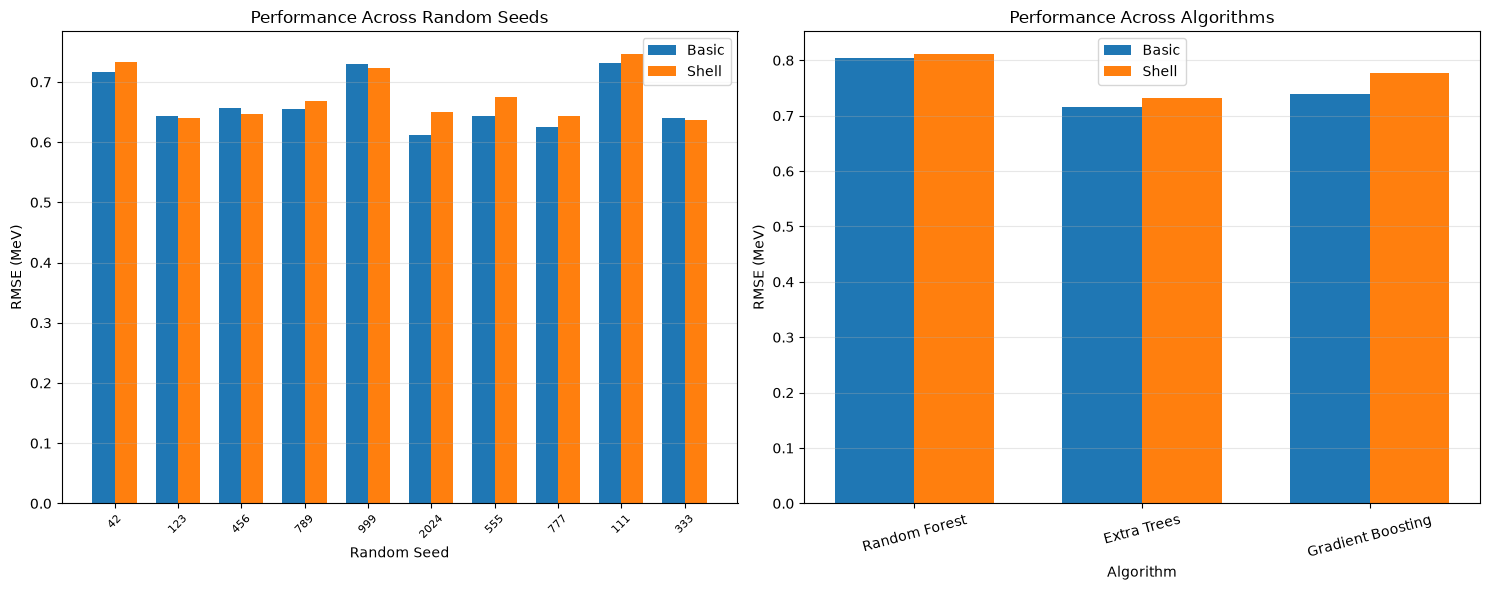


PHASE 8.4 — ROBUSTNESS SUMMARY

Random-seed analysis:
  Basic model: 0.6651 ± 0.0420 MeV
  Shell model: 0.6761 ± 0.0398 MeV
  Basic wins: 6/10
  Shell wins: 4/10

Algorithm analysis:
  Random Forest: Basic (ΔRMSE = -0.0080 MeV)
  Extra Trees: Basic (ΔRMSE = -0.0164 MeV)
  Gradient Boosting: Basic (ΔRMSE = -0.0373 MeV)

PHASE 8 — ROBUSTNESS ANALYSIS COMPLETED


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")


# ============================================================================
# PHASE 8 — ROBUSTNESS ANALYSIS
# ============================================================================
# Objective:
# Evaluate whether the observed performance difference between the Basic
# and Shell feature sets is robust to:
#   1. Different random seeds
#   2. Different machine-learning algorithms
#
# The analysis compares:
#   Basic Model:
#       Z, N, A, neutron excess, proton parity, neutron parity
#
#   Shell Model:
#       Z, N, A, neutron excess, neutron valence,
#       neutron magic-number distance, proton magic-number distance
# ============================================================================

print("=" * 70)
print("PHASE 8 — ROBUSTNESS ANALYSIS")
print("=" * 70)

target = "residual"

features_basic = [
    "z",
    "n",
    "a",
    "neutron_excess",
    "parity_Z",
    "parity_N"
]

features_shell = [
    "z",
    "n",
    "a",
    "neutron_excess",
    "valence_N",
    "magic_dist_N",
    "magic_dist_Z"
]

seeds = [42, 123, 456, 789, 999, 2024, 555, 777, 111, 333]

print(f"Dataset size: {len(df_full)} nuclei")
print(f"Basic features: {len(features_basic)}")
print(f"Shell features: {len(features_shell)}")


# ============================================================================
# PHASE 8.1 — RANDOM-SEED ROBUSTNESS
# ============================================================================
# The same 5-fold cross-validation procedure is repeated using ten different
# random seeds.
#
# This tests whether the relative performance of the Basic and Shell models
# depends strongly on a particular train/test split.
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 8.1 — RANDOM-SEED ROBUSTNESS")
print("=" * 70)

results_seeds = {
    "Basic": [],
    "Shell": []
}

for seed in seeds:

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    rmse_basic = []
    rmse_shell = []

    for train_idx, test_idx in kf.split(df_full):

        train_data = df_full.iloc[train_idx]
        test_data = df_full.iloc[test_idx]

        # ------------------------------------------------------------------
        # Basic model
        # ------------------------------------------------------------------

        model_basic = ExtraTreesRegressor(
            n_estimators=300,
            random_state=seed,
            n_jobs=-1
        )

        model_basic.fit(
            train_data[features_basic],
            train_data[target]
        )

        pred_basic = model_basic.predict(
            test_data[features_basic]
        )

        rmse_basic.append(
            root_mean_squared_error(
                test_data[target],
                pred_basic
            )
        )

        # ------------------------------------------------------------------
        # Shell model
        # ------------------------------------------------------------------

        model_shell = ExtraTreesRegressor(
            n_estimators=300,
            random_state=seed,
            n_jobs=-1
        )

        model_shell.fit(
            train_data[features_shell],
            train_data[target]
        )

        pred_shell = model_shell.predict(
            test_data[features_shell]
        )

        rmse_shell.append(
            root_mean_squared_error(
                test_data[target],
                pred_shell
            )
        )

    results_seeds["Basic"].append(np.mean(rmse_basic))
    results_seeds["Shell"].append(np.mean(rmse_shell))


# ---------------------------------------------------------------------------
# Random-seed results
# ---------------------------------------------------------------------------

print(
    f"\n{'Seed':>6s} | "
    f"{'Basic':>10s} | "
    f"{'Shell':>10s} | "
    f"{'Basic - Shell':>14s} | "
    f"{'Winner':>10s}"
)

print("-" * 65)

for i, seed in enumerate(seeds):

    basic_rmse = results_seeds["Basic"][i]
    shell_rmse = results_seeds["Shell"][i]

    difference = basic_rmse - shell_rmse

    if difference < 0:
        winner = "Basic"
    elif difference > 0:
        winner = "Shell"
    else:
        winner = "Tie"

    print(
        f"{seed:6d} | "
        f"{basic_rmse:10.4f} | "
        f"{shell_rmse:10.4f} | "
        f"{difference:+14.4f} | "
        f"{winner:>10s}"
    )


mean_basic_seed = np.mean(results_seeds["Basic"])
std_basic_seed = np.std(results_seeds["Basic"])

mean_shell_seed = np.mean(results_seeds["Shell"])
std_shell_seed = np.std(results_seeds["Shell"])

mean_difference = mean_basic_seed - mean_shell_seed

basic_wins = sum(
    basic < shell
    for basic, shell in zip(
        results_seeds["Basic"],
        results_seeds["Shell"]
    )
)

shell_wins = len(seeds) - basic_wins


print("\nRandom-seed summary:")
print(
    f"  Basic: "
    f"{mean_basic_seed:.4f} ± {std_basic_seed:.4f} MeV"
)

print(
    f"  Shell: "
    f"{mean_shell_seed:.4f} ± {std_shell_seed:.4f} MeV"
)

print(
    f"  Mean RMSE difference (Basic - Shell): "
    f"{mean_difference:+.4f} MeV"
)

print(
    f"  Basic model wins: "
    f"{basic_wins}/{len(seeds)} seeds"
)

print(
    f"  Shell model wins: "
    f"{shell_wins}/{len(seeds)} seeds"
)


# ============================================================================
# PHASE 8.2 — ALGORITHM ROBUSTNESS
# ============================================================================
# The Basic and Shell feature sets are evaluated using three different
# tree-based regression algorithms:
#
#   1. Random Forest
#   2. Extra Trees
#   3. Gradient Boosting
#
# A fixed 5-fold split is used for direct comparison.
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 8.2 — ALGORITHM ROBUSTNESS")
print("=" * 70)

algorithms = {
    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": lambda: ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": lambda: GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

algorithm_results = {}

for algorithm_name, model_factory in algorithms.items():

    basic_rmse = []
    shell_rmse = []

    for train_idx, test_idx in kf.split(df_full):

        train_data = df_full.iloc[train_idx]
        test_data = df_full.iloc[test_idx]

        # ------------------------------------------------------------------
        # Basic model
        # ------------------------------------------------------------------

        model_basic = model_factory()

        model_basic.fit(
            train_data[features_basic],
            train_data[target]
        )

        pred_basic = model_basic.predict(
            test_data[features_basic]
        )

        basic_rmse.append(
            root_mean_squared_error(
                test_data[target],
                pred_basic
            )
        )

        # ------------------------------------------------------------------
        # Shell model
        # ------------------------------------------------------------------

        model_shell = model_factory()

        model_shell.fit(
            train_data[features_shell],
            train_data[target]
        )

        pred_shell = model_shell.predict(
            test_data[features_shell]
        )

        shell_rmse.append(
            root_mean_squared_error(
                test_data[target],
                pred_shell
            )
        )

    mean_basic = np.mean(basic_rmse)
    mean_shell = np.mean(shell_rmse)

    std_basic = np.std(basic_rmse)
    std_shell = np.std(shell_rmse)

    algorithm_results[algorithm_name] = {
        "Basic_mean": mean_basic,
        "Basic_std": std_basic,
        "Shell_mean": mean_shell,
        "Shell_std": std_shell,
        "Difference": mean_basic - mean_shell
    }


# ---------------------------------------------------------------------------
# Algorithm comparison table
# ---------------------------------------------------------------------------

print(
    f"\n{'Algorithm':20s} | "
    f"{'Basic RMSE':>12s} | "
    f"{'Shell RMSE':>12s} | "
    f"{'Difference':>12s} | "
    f"{'Winner':>10s}"
)

print("-" * 75)

for algorithm_name, result in algorithm_results.items():

    difference = result["Difference"]

    if difference < 0:
        winner = "Basic"
    elif difference > 0:
        winner = "Shell"
    else:
        winner = "Tie"

    print(
        f"{algorithm_name:20s} | "
        f"{result['Basic_mean']:.4f} ± {result['Basic_std']:.4f} | "
        f"{result['Shell_mean']:.4f} ± {result['Shell_std']:.4f} | "
        f"{difference:+12.4f} | "
        f"{winner:>10s}"
    )


# ============================================================================
# PHASE 8.3 — VISUALIZATION
# ============================================================================
# Two complementary visualizations are generated:
#
#   1. RMSE stability across random seeds
#   2. Basic vs Shell performance across algorithms
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 8.3 — ROBUSTNESS VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)


# ---------------------------------------------------------------------------
# Plot 1 — Random-seed robustness
# ---------------------------------------------------------------------------

x = np.arange(len(seeds))
width = 0.35

axes[0].bar(
    x - width / 2,
    results_seeds["Basic"],
    width,
    label="Basic"
)

axes[0].bar(
    x + width / 2,
    results_seeds["Shell"],
    width,
    label="Shell"
)

axes[0].set_xlabel("Random Seed")
axes[0].set_ylabel("RMSE (MeV)")
axes[0].set_title("Performance Across Random Seeds")

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    seeds,
    rotation=45,
    fontsize=8
)

axes[0].legend()
axes[0].grid(
    True,
    alpha=0.3,
    axis="y"
)


# ---------------------------------------------------------------------------
# Plot 2 — Algorithm robustness
# ---------------------------------------------------------------------------

algorithm_names = list(algorithm_results.keys())

basic_algorithm_rmse = [
    algorithm_results[name]["Basic_mean"]
    for name in algorithm_names
]

shell_algorithm_rmse = [
    algorithm_results[name]["Shell_mean"]
    for name in algorithm_names
]

x = np.arange(len(algorithm_names))

axes[1].bar(
    x - width / 2,
    basic_algorithm_rmse,
    width,
    label="Basic"
)

axes[1].bar(
    x + width / 2,
    shell_algorithm_rmse,
    width,
    label="Shell"
)

axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("RMSE (MeV)")
axes[1].set_title("Performance Across Algorithms")

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    algorithm_names,
    rotation=15
)

axes[1].legend()
axes[1].grid(
    True,
    alpha=0.3,
    axis="y"
)

plt.tight_layout()
plt.show()


# ============================================================================
# PHASE 8.4 — FINAL ROBUSTNESS SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 8.4 — ROBUSTNESS SUMMARY")
print("=" * 70)

print("\nRandom-seed analysis:")
print(
    f"  Basic model: "
    f"{mean_basic_seed:.4f} ± {std_basic_seed:.4f} MeV"
)

print(
    f"  Shell model: "
    f"{mean_shell_seed:.4f} ± {std_shell_seed:.4f} MeV"
)

print(
    f"  Basic wins: "
    f"{basic_wins}/{len(seeds)}"
)

print(
    f"  Shell wins: "
    f"{shell_wins}/{len(seeds)}"
)

print("\nAlgorithm analysis:")

for algorithm_name, result in algorithm_results.items():

    difference = result["Difference"]

    if difference < 0:
        winner = "Basic"
    elif difference > 0:
        winner = "Shell"
    else:
        winner = "Tie"

    print(
        f"  {algorithm_name}: "
        f"{winner} "
        f"(ΔRMSE = {difference:+.4f} MeV)"
    )

print("\n" + "=" * 70)
print("PHASE 8 — ROBUSTNESS ANALYSIS COMPLETED")
print("=" * 70)

In [16]:
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.model_selection import GridSearchCV, KFold

import warnings
warnings.filterwarnings("ignore")


# ============================================================================
# PHASE 9 — HYPERPARAMETER OPTIMIZATION
# ============================================================================
# Objective:
# Optimize the hyperparameters of the three tree-based models used in the
# previous robustness analysis.
#
# Feature set:
#   Basic model
#   Z, N, A, neutron excess, proton parity, neutron parity
#
# Models:
#   1. Extra Trees
#   2. Random Forest
#   3. Gradient Boosting
#
# Evaluation:
#   5-fold cross-validation
#   Scoring metric: RMSE
#
# The optimized models are compared against their default configurations.
# ============================================================================

print("=" * 70)
print("PHASE 9 — HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

target = "residual"

features_optimal = [
    "z",
    "n",
    "a",
    "neutron_excess",
    "parity_Z",
    "parity_N"
]

rms_semf = 5.5603

# Fixed cross-validation strategy
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = df_full[features_optimal]
y = df_full[target]

print(f"Dataset size: {len(df_full)} nuclei")
print(f"Number of features: {len(features_optimal)}")
print(f"Features: {features_optimal}")
print("Cross-validation: 5-fold")
print("Scoring: RMSE")


# ============================================================================
# PHASE 9.1 — EXTRA TREES GRID SEARCH
# ============================================================================
# Search space:
#   n_estimators     → number of trees
#   max_depth        → maximum tree depth
#   min_samples_leaf → minimum number of samples in a leaf
#
# A reduced grid is used to keep the computational cost reasonable.
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 9.1 — EXTRA TREES GRID SEARCH")
print("=" * 70)

param_grid_et = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 20, 30],
    "min_samples_leaf": [1, 2]
}

total_combinations_et = (
    len(param_grid_et["n_estimators"])
    * len(param_grid_et["max_depth"])
    * len(param_grid_et["min_samples_leaf"])
)

print(f"Parameter combinations: {total_combinations_et}")
print("Starting GridSearchCV...")

grid_et = GridSearchCV(
    estimator=ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_et,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_et.fit(X, y)

et_best_rmse = -grid_et.best_score_

print("\nBest Extra Trees parameters:")
for parameter, value in grid_et.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"\nBest 5-fold CV RMSE: {et_best_rmse:.4f} MeV")

et_default_rmse = 0.7164

print(f"Default RMSE: {et_default_rmse:.4f} MeV")
print(
    f"Improvement: "
    f"{et_default_rmse - et_best_rmse:+.4f} MeV"
)


# ============================================================================
# PHASE 9.2 — RANDOM FOREST GRID SEARCH
# ============================================================================
# The same general search strategy is applied to Random Forest.
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 9.2 — RANDOM FOREST GRID SEARCH")
print("=" * 70)

param_grid_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 20, 30],
    "min_samples_leaf": [1, 2]
}

total_combinations_rf = (
    len(param_grid_rf["n_estimators"])
    * len(param_grid_rf["max_depth"])
    * len(param_grid_rf["min_samples_leaf"])
)

print(f"Parameter combinations: {total_combinations_rf}")
print("Starting GridSearchCV...")

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X, y)

rf_best_rmse = -grid_rf.best_score_

print("\nBest Random Forest parameters:")
for parameter, value in grid_rf.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"\nBest 5-fold CV RMSE: {rf_best_rmse:.4f} MeV")

rf_default_rmse = 0.8037

print(f"Default RMSE: {rf_default_rmse:.4f} MeV")
print(
    f"Improvement: "
    f"{rf_default_rmse - rf_best_rmse:+.4f} MeV"
)


# ============================================================================
# PHASE 9.3 — GRADIENT BOOSTING GRID SEARCH
# ============================================================================
# Search space:
#   n_estimators
#   max_depth
#   learning_rate
#
# These parameters control the number, complexity and contribution of the
# boosting stages.
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 9.3 — GRADIENT BOOSTING GRID SEARCH")
print("=" * 70)

param_grid_gb = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1]
}

total_combinations_gb = (
    len(param_grid_gb["n_estimators"])
    * len(param_grid_gb["max_depth"])
    * len(param_grid_gb["learning_rate"])
)

print(f"Parameter combinations: {total_combinations_gb}")
print("Starting GridSearchCV...")

grid_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=param_grid_gb,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X, y)

gb_best_rmse = -grid_gb.best_score_

print("\nBest Gradient Boosting parameters:")
for parameter, value in grid_gb.best_params_.items():
    print(f"  {parameter}: {value}")

print(f"\nBest 5-fold CV RMSE: {gb_best_rmse:.4f} MeV")

gb_default_rmse = 0.7398

print(f"Default RMSE: {gb_default_rmse:.4f} MeV")
print(
    f"Improvement: "
    f"{gb_default_rmse - gb_best_rmse:+.4f} MeV"
)


# ============================================================================
# PHASE 9.4 — MODEL COMPARISON
# ============================================================================
# Compare default and optimized configurations using the same RMSE metric.
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 9.4 — DEFAULT vs OPTIMIZED MODELS")
print("=" * 70)

model_results = {
    "Extra Trees": {
        "default": et_default_rmse,
        "optimized": et_best_rmse
    },
    "Random Forest": {
        "default": rf_default_rmse,
        "optimized": rf_best_rmse
    },
    "Gradient Boosting": {
        "default": gb_default_rmse,
        "optimized": gb_best_rmse
    }
}

print(
    f"\n{'Model':20s} | "
    f"{'Default':>10s} | "
    f"{'Optimized':>10s} | "
    f"{'Improvement':>12s}"
)

print("-" * 65)

for model_name, result in model_results.items():

    improvement = (
        result["default"]
        - result["optimized"]
    )

    print(
        f"{model_name:20s} | "
        f"{result['default']:10.4f} | "
        f"{result['optimized']:10.4f} | "
        f"{improvement:+12.4f}"
    )


# ============================================================================
# PHASE 9.5 — BEST OPTIMIZED MODEL
# ============================================================================

best_model_name = min(
    model_results,
    key=lambda name: model_results[name]["optimized"]
)

best_rmse = model_results[best_model_name]["optimized"]

semf_improvement = rms_semf - best_rmse
semf_improvement_percent = (
    semf_improvement / rms_semf * 100
)

print("\n" + "=" * 70)
print("PHASE 9.5 — BEST OPTIMIZED MODEL")
print("=" * 70)

print(f"\nBest model: {best_model_name}")
print(f"Optimized RMSE: {best_rmse:.4f} MeV")

print(
    f"Improvement over SEMF: "
    f"{semf_improvement:.4f} MeV"
)

print(
    f"Relative improvement over SEMF: "
    f"{semf_improvement_percent:.2f}%"
)


# ============================================================================
# PHASE 9.6 — BEST HYPERPARAMETERS
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 9.6 — BEST HYPERPARAMETERS")
print("=" * 70)

if best_model_name == "Extra Trees":

    best_params = grid_et.best_params_

elif best_model_name == "Random Forest":

    best_params = grid_rf.best_params_

else:

    best_params = grid_gb.best_params_


for parameter, value in best_params.items():
    print(f"  {parameter}: {value}")


# ============================================================================
# PHASE 9.7 — TRAIN FINAL OPTIMIZED MODEL
# ============================================================================
# The best hyperparameter configuration identified by cross-validation is
# used to train the final model on the complete dataset.
#
# Important:
# The performance reported above remains the cross-validation performance.
# The final model below is trained on all available nuclei for later use.
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 9.7 — FINAL OPTIMIZED MODEL")
print("=" * 70)

if best_model_name == "Extra Trees":

    final_model = ExtraTreesRegressor(
        **grid_et.best_params_,
        random_state=42,
        n_jobs=-1
    )

elif best_model_name == "Random Forest":

    final_model = RandomForestRegressor(
        **grid_rf.best_params_,
        random_state=42,
        n_jobs=-1
    )

else:

    final_model = GradientBoostingRegressor(
        **grid_gb.best_params_,
        random_state=42
    )


final_model.fit(X, y)

print(f"\nFinal model: {best_model_name}")
print("Final model trained on all available nuclei.")

print("\nFinal parameters:")
for parameter, value in final_model.get_params().items():

    if parameter in best_params:
        print(f"  {parameter}: {value}")


# ============================================================================
# PHASE 9.8 — FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 9 — FINAL SUMMARY")
print("=" * 70)

print(f"""
Dataset size:
    {len(df_full)} nuclei

Feature set:
    Basic feature set

SEMF baseline:
    {rms_semf:.4f} MeV

Extra Trees:
    Default   = {et_default_rmse:.4f} MeV
    Optimized = {et_best_rmse:.4f} MeV

Random Forest:
    Default   = {rf_default_rmse:.4f} MeV
    Optimized = {rf_best_rmse:.4f} MeV

Gradient Boosting:
    Default   = {gb_default_rmse:.4f} MeV
    Optimized = {gb_best_rmse:.4f} MeV

Best optimized model:
    {best_model_name}

Best optimized CV RMSE:
    {best_rmse:.4f} MeV

Improvement over SEMF:
    {semf_improvement:.4f} MeV
    ({semf_improvement_percent:.2f}%)
""")

print("=" * 70)
print("PHASE 9 — HYPERPARAMETER OPTIMIZATION COMPLETED")
print("=" * 70)

PHASE 9 — HYPERPARAMETER OPTIMIZATION
Dataset size: 3555 nuclei
Number of features: 6
Features: ['z', 'n', 'a', 'neutron_excess', 'parity_Z', 'parity_N']
Cross-validation: 5-fold
Scoring: RMSE

PHASE 9.1 — EXTRA TREES GRID SEARCH
Parameter combinations: 18
Starting GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Extra Trees parameters:
  max_depth: 30
  min_samples_leaf: 1
  n_estimators: 500

Best 5-fold CV RMSE: 0.7084 MeV
Default RMSE: 0.7164 MeV
Improvement: +0.0080 MeV

PHASE 9.2 — RANDOM FOREST GRID SEARCH
Parameter combinations: 18
Starting GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Random Forest parameters:
  max_depth: 30
  min_samples_leaf: 1
  n_estimators: 500

Best 5-fold CV RMSE: 0.7977 MeV
Default RMSE: 0.8037 MeV
Improvement: +0.0060 MeV

PHASE 9.3 — GRADIENT BOOSTING GRID SEARCH
Parameter combinations: 18
Starting GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best